# UFC Analytics Platform â€” Project Writeup

**Goal:** Build a production-grade ML system to predict UFC fight outcomes using only information available before each fight (strictly no data leakage).

**Stack:** Python Â· PostgreSQL (Supabase) Â· FastAPI Â· scikit-learn Â· XGBoost Â· SHAP

**Reference methodology:** Turgut (2021), Tilburg University â€” *"Machine Learning approach to predicting MMA matches"*

---

## Pipeline Overview

```
UFCStats.com scraping
      â†“
PostgreSQL (Supabase) â€” 756 events, 4,449 fighters, 8,482 fights
      â†“
ETL pipeline (4 phases) â€” FK resolution, type parsing, derived columns
      â†“
Feature engineering (7 modules) â€” 71 candidate features
      â†“
Feature selection (MI + collinearity) â€” 31 features selected
      â†“
Temporal split 70 / 15 / 15
      â†“
Win/loss model â€” LR, XGBoost, Random Forest â†’ best: RF  test_acc=63.85%  test_AUC=0.6785
Method model   â€” Random Forest (3-class: KO/TKO | Submission | Decision)  test_acc=~49%
      â†“
SHAP interpretation (win/loss model)
```

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Image, display

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Paths (notebook lives in docs/, data lives in backend/)
ROOT     = Path('..').resolve()
BACKEND  = ROOT / 'backend'
FEATURES = BACKEND / 'features'
MODELS   = BACKEND / 'models'
EDA      = ROOT / 'eda'

print('Root:', ROOT)
print('Parquet:', (FEATURES / 'training_data.parquet').exists())
print('Models dir:', MODELS.exists())

Root: C:\Users\kabec\Documents\ufc_analytics_platform
Parquet: True
Models dir: True


---
## Phase 1: Data Collection

**Source:** [UFCStats.com](http://ufcstats.com) â€” the official statistical record for every UFC event since 1994.

**Scraper:** A custom BeautifulSoup scraper (`live_scraper.py`) writes to six PostgreSQL tables hosted on Supabase. A GitHub Actions workflow runs it weekly after each UFC event.

### Database Schema

| Table | Rows | Description |
|---|---|---|
| `event_details` | 756 | UFC events with date and location |
| `fighter_details` | 4,449 | Fighter profiles (name, URL) |
| `fighter_tott` | 4,435 | Tale of the Tape: height, weight, reach, DOB, stance |
| `fight_details` | 8,482 | Fight matchups with FK to event |
| `fight_results` | 8,482 | Outcome, method, round, time |
| `fight_stats` | 39,912 | Per-fighter, per-round statistics |

All six tables are FK-linked with 99.75%+ coverage across all relationships.

**Date range:** 1994-03-11 (UFC 1) to 2025-12-07 (Fight Night: Covington vs. Buckley)

In [2]:
# Load the training parquet â€” every row is one fight from one fighter's perspective
df = pd.read_parquet(FEATURES / 'training_data.parquet')
df['event_date'] = pd.to_datetime(df['event_date'])

print(f"Training matrix shape: {df.shape}")
print(f"Date range: {df['event_date'].min().date()} to {df['event_date'].max().date()}")
print(f"Unique fights: {df['fight_id'].nunique()}")

Training matrix shape: (6230, 78)
Date range: 1998-10-16 to 2026-02-28
Unique fights: 6230


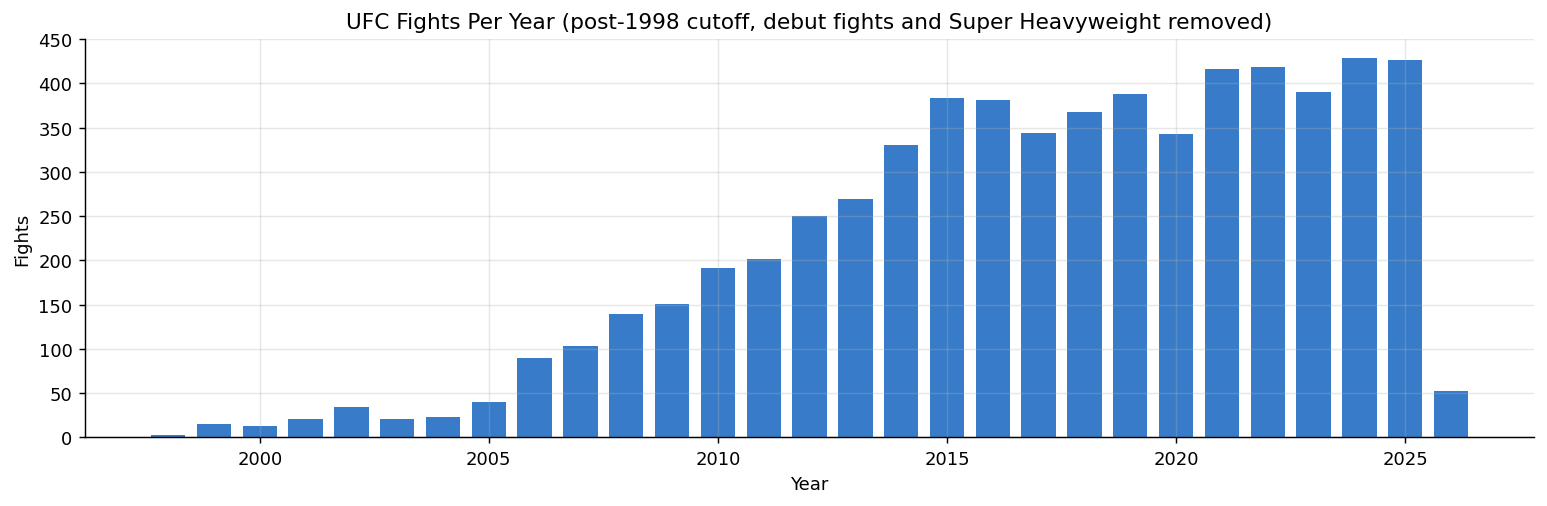

In [3]:
# Fights per year in the training set
fights_by_year = (
    df.drop_duplicates(subset='fight_id')
      .set_index('event_date')
      .resample('YE')
      .size()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(fights_by_year.index.year, fights_by_year.values, color='#1565C0', alpha=0.85, width=0.75)
ax.set_xlabel('Year')
ax.set_ylabel('Fights')
ax.set_title('UFC Fights Per Year (post-1998 cutoff, debut fights and Super Heavyweight removed)')
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
plt.tight_layout()
plt.show()

---
## Phase 2: ETL Pipeline

Raw scraped data has several data quality problems that must be resolved before any feature engineering.

### Four-phase ETL (`post_scrape_clean.py`)

| Phase | What it does | Example |
|---|---|---|
| **1. FK Resolution** | Match fighter names to database IDs via URL; link every fight to its fighters | `"Conor McGregor"` â†’ `fighter_id=abc123` |
| **2. Quality Cleanup** | Replace `"--"` placeholders with NULL; strip trailing spaces | `"--"` â†’ `NULL` |
| **3. Type Parsing** | Parse `"17 of 37"` â†’ integers; `"1:23"` â†’ 83 seconds; height/reach strings â†’ floats | Typed numeric columns |
| **4. Derived Columns** | Infer weight class from bout string; set title fight and championship round flags | `"UFC Heavyweight Championship"` â†’ `is_title_fight=1` |

A standalone `validate_etl.py` script exits with code 1 if quality thresholds are not met, and is integrated into the weekly GitHub Actions workflow.

### Three Data Quality Filters (following Tilburg 2021)

| Filter | Rows removed | Reason |
|---|---|---|
| Pre-October 1998 cutoff | 169 | Early UFC had frequent missing statistics |
| Debut fights | 2,009 | Either fighter's first UFC appearance â€” all stat features would be zero (noise) |
| Super Heavyweight / Open Weight | 1 | No weight limit â€” incompatible with weight class features |

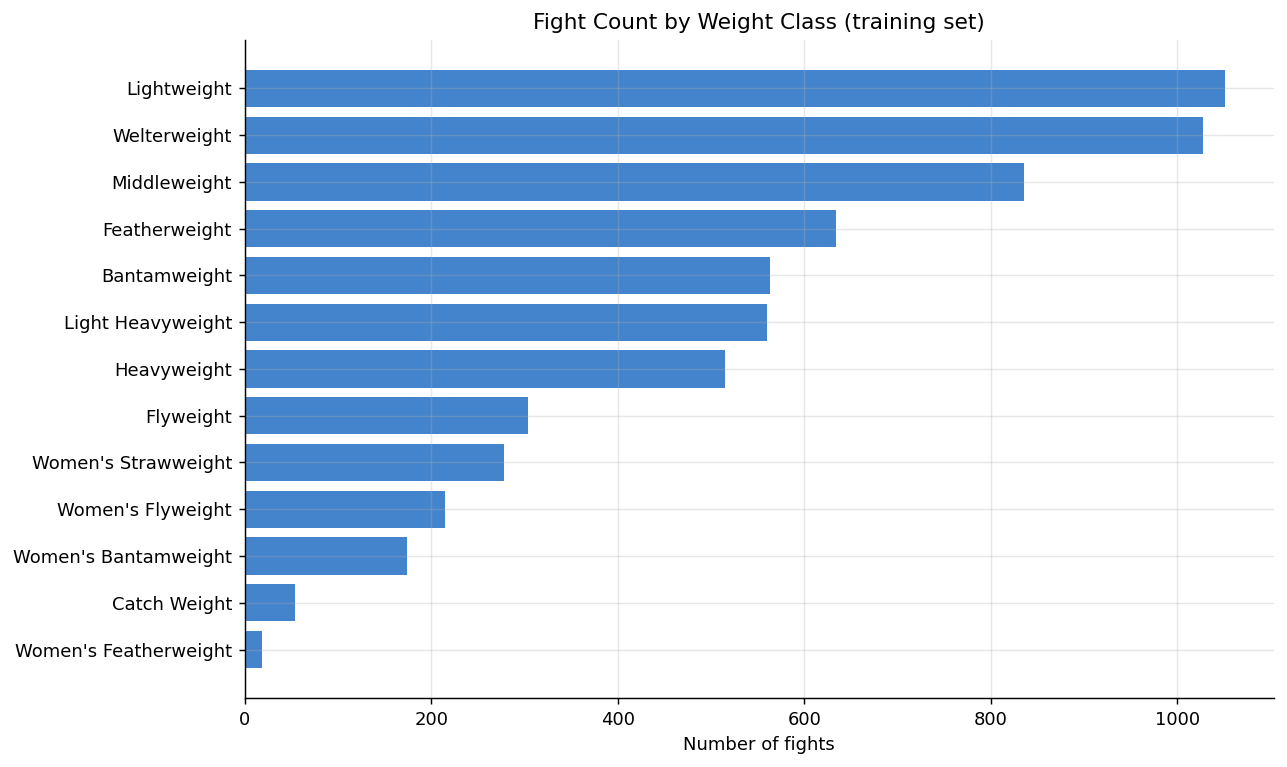

In [4]:
# Fight count by weight class
wc_counts = (
    df.drop_duplicates(subset='fight_id')['weight_class']
      .value_counts()
      .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(wc_counts.index, wc_counts.values, color='#1565C0', alpha=0.8)
ax.set_xlabel('Number of fights')
ax.set_title('Fight Count by Weight Class (training set)')
plt.tight_layout()
plt.show()

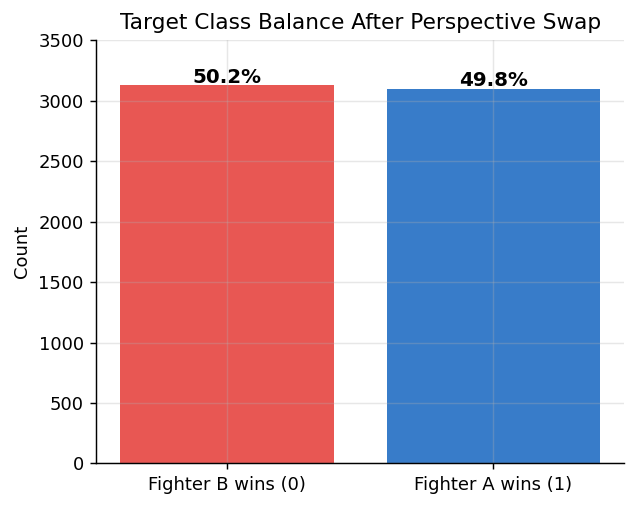

Class balance: Fighter A wins 49.8% / Fighter B wins 50.2%


In [5]:
# Target balance â€” should be ~50/50 after random perspective swap
target_counts = df['fighter_a_wins'].value_counts()
pct = target_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Fighter B wins (0)', 'Fighter A wins (1)'], target_counts.values,
       color=['#E53935', '#1565C0'], alpha=0.85)
for i, (v, p) in enumerate(zip(target_counts.values, pct.values)):
    ax.text(i, v + 20, f'{p:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Target Class Balance After Perspective Swap')
ax.set_ylim(0, max(target_counts.values) * 1.12)
plt.tight_layout()
plt.show()

print(f"Class balance: Fighter A wins {pct.get(1, 0):.1f}% / Fighter B wins {pct.get(0, 0):.1f}%")

---
## Phase 3: Feature Engineering

All features are **point-in-time correct** â€” every value at fight `i` reflects only fights `0 â€¦ i-1`. This prevents information leakage.

### Seven Feature Modules

| Module | Output | Key technique |
|---|---|---|
| `differentials.py` | Win rate, win/loss streaks, experience, opponent quality | `cumsum().shift(1)` |
| `rolling_metrics.py` | 3/5/7-fight rolling avg + career avg per stat | `rolling(N).mean().shift(1)`, `expanding().mean().shift(1)` |
| `style_features.py` | Grappling ratio, aggression score, KO rate, decision rate, defense score | `cumsum().shift(1)` per-fight |
| `time_features.py` | Age at fight, career length, days in weight class, days since last fight | Date arithmetic |
| `opponent_quality.py` | Avg opponent losses, strength of schedule | Point-in-time opponent record lookup |
| `differentials.py` | Physical diffs: reach, weight | From `fighter_tott` table |
| `pipeline.py` | Assembles all modules, applies perspective swap | Negates all `diff_*` columns for swapped rows |

### Naming Conventions

Every feature name follows a consistent pattern:

| Prefix / Suffix | Meaning |
|---|---|
| `diff_` prefix | Fighter A value minus Fighter B value. **Positive = Fighter A has the advantage.** |
| `roll3_` / `roll5_` / `roll7_` | Rolling average over the fighter's last 3, 5, or 7 fights |
| `career_avg_` | Expanding average â€” mean over all prior fights (not just last N) |
| `ewa_` | Exponentially weighted average â€” like career_avg but recent fights count more (Î±=0.5) |
| `_pct` | A percentage or ratio (0 to 1) |
| `_s` | Time in seconds |
| `_att` | Attempts (not completions) |
| `is_` prefix | Binary flag: 1 = yes, 0 = no |

### Feature Glossary â€” All 31 Selected Features

All `diff_*` features follow the convention: **positive value = Fighter A has more of that quality.**

---

#### Physical Attributes

| Feature | Plain English |
|---|---|
| `diff_age_at_fight` | Age gap in days at fight date (Fighter A âˆ’ Fighter B). Positive = Fighter A is older. Older fighters may have more experience but more wear. |
| `reach_diff_inches` | Reach gap in inches (Fighter A âˆ’ Fighter B). Positive = Fighter A has longer arms. Traditionally advantageous in striking. |
| `weight_diff_lbs` | Weight gap at weigh-in (Fighter A âˆ’ Fighter B). Usually 0 within a class; non-zero in catch weight fights. |

---

#### Record & Momentum

| Feature | Plain English |
|---|---|
| `win_rate_diff` | Difference in win rate (wins Ã· total fights), computed point-in-time before this fight. Positive = Fighter A has won a higher proportion of their UFC career. |
| `win_streak_diff` | Difference in current win streak (consecutive UFC wins entering this fight). Positive = Fighter A is on a longer hot streak. |
| `loss_streak_diff` | Difference in current loss streak (consecutive losses). Positive = Fighter A has more consecutive losses â€” a bad sign. |
| `diff_career_length_days` | Difference in UFC career length in days (first UFC fight to now). Positive = Fighter A has been in the UFC longer. |
| `diff_days_in_weight_class` | Difference in days spent at this specific weight class. Captures experience at the exact division, not just UFC tenure. |

---

#### Striking Output (Recent Form)

| Feature | Plain English |
|---|---|
| `diff_roll7_sig_str_pct` | Difference in significant strike accuracy over the last 7 fights (landed Ã· attempted). Positive = Fighter A is more precise. |
| `diff_roll7_sig_str_att` | Difference in significant strikes attempted per fight, last 7 fights. Positive = Fighter A throws more sig strikes. |
| `diff_roll3_sig_str_landed` | Difference in significant strikes landed per fight, last **3** fights (most recent form). |
| `diff_roll7_total_str_landed` | Difference in all strikes landed per fight (including body, leg, head), last 7 fights. |
| `diff_roll3_total_str_landed` | Same as above but last 3 fights â€” captures very recent output volume. |
| `diff_roll7_kd` | Difference in average knockdowns scored per fight, last 7 fights. Positive = Fighter A drops opponents more. |
| `diff_ewa_kd` | Same as above but exponentially weighted â€” very recent fights count more. |

---

#### Striking Output (Career Baseline)

| Feature | Plain English |
|---|---|
| `diff_career_avg_total_str_attempted` | Difference in career average total strikes attempted per fight. Captures long-run output volume, less sensitive to recent form. |

---

#### Grappling

| Feature | Plain English |
|---|---|
| `diff_roll7_td_landed` | Difference in takedowns landed per fight, last 7 fights. Positive = Fighter A completes more TDs recently. |
| `diff_roll5_td_pct` | Difference in takedown accuracy (landed Ã· attempted) over the last 5 fights. Positive = Fighter A converts TDs at a higher rate. |
| `diff_career_avg_td_attempted` | Difference in career average takedown attempts per fight. Captures how frequently a fighter shoots for TDs overall. |
| `diff_roll3_ctrl_s` | Difference in ground control time in seconds, last 3 fights. Positive = Fighter A dominates on the mat more recently. |
| `diff_career_avg_ctrl_s` | Difference in career average control time per fight. Long-run grappling dominance baseline. |
| `diff_td_def_rate` | Difference in takedown defense rate (% of opponent TD attempts stuffed). Positive = Fighter A is better at stopping takedowns. |

---

#### Style Signals

| Feature | Plain English |
|---|---|
| `diff_grappling_ratio` | Difference in grappling ratio: what fraction of a fighter's offensive output is grappling (TDs + control) vs striking. Positive = Fighter A is more grappling-oriented. |
| `diff_aggression_score` | Difference in aggression score: total offensive actions (strikes + TDs) per minute of fight time. Positive = Fighter A pushes the pace harder. |
| `diff_ko_rate` | Difference in KO/TKO finish rate (KO wins Ã· total fights). Positive = Fighter A finishes more fights by stoppage. |
| `diff_decision_rate` | Difference in decision rate (fights going to judges Ã· total fights). Positive = Fighter A is more likely to go the distance. |
| `diff_sapm` | **Strikes Absorbed Per Minute** difference. SAPM = how many significant strikes a fighter eats per minute of fight time, based on career history. **Higher SAPM = gets hit more = typically a disadvantage.** Positive `diff_sapm` means Fighter A absorbs more strikes. |
| `diff_defense_score` | Difference in defense score: significant strikes absorbed per minute (similar to SAPM but computed from our fight_stats data rather than UFCStats career summary). Lower = harder to hit. Positive = Fighter A absorbs more â€” unfavorable. |

---

#### Opponent Quality

| Feature | Plain English |
|---|---|
| `diff_avg_opponent_losses` | Difference in average losses of past opponents. **Higher = Fighter A has faced weaker opponents** (opponents with more losses). A measure of schedule difficulty. |

---

#### Fight Context (Binary Flags)

| Feature | Plain English |
|---|---|
| `is_title_fight` | 1 if this is a UFC title or interim title fight, 0 otherwise. Title fights are scheduled for 5 rounds; fighters may be more conservative. |
| `is_women_division` | 1 if this is a women's weight class fight (Strawweight, Flyweight, Bantamweight, Featherweight). Fighting patterns differ between men's and women's divisions. |

---

#### Categorical Feature

| Feature | Plain English |
|---|---|
| `weight_class` | Which weight division the fight takes place in. Encoded as an ordered integer from lightest (Women's Strawweight = 0) to heaviest (Heavyweight = 11). |

In [6]:
with open(FEATURES / 'selected_features.json') as f:
    sel = json.load(f)

feature_names = sel['feature_names']
print(f"Selected features ({len(feature_names)}):")
for i, f in enumerate(feature_names, 1):
    print(f"  {i:2d}. {f}")

Selected features (31):
   1. diff_age_at_fight
   2. win_rate_diff
   3. diff_grappling_ratio
   4. diff_roll7_total_str_landed
   5. diff_roll7_sig_str_pct
   6. diff_career_avg_td_attempted
   7. win_streak_diff
   8. diff_career_length_days
   9. diff_days_in_weight_class
  10. diff_roll7_sig_str_att
  11. is_title_fight
  12. diff_roll3_sig_str_landed
  13. diff_avg_opponent_losses
  14. diff_aggression_score
  15. diff_roll7_td_landed
  16. diff_ko_rate
  17. diff_roll5_td_pct
  18. diff_roll3_ctrl_s
  19. diff_sapm
  20. diff_roll7_kd
  21. diff_career_avg_ctrl_s
  22. diff_roll3_total_str_landed
  23. is_women_division
  24. diff_career_avg_total_str_attempted
  25. diff_decision_rate
  26. diff_ewa_kd
  27. reach_diff_inches
  28. loss_streak_diff
  29. diff_defense_score
  30. weight_diff_lbs
  31. diff_td_def_rate


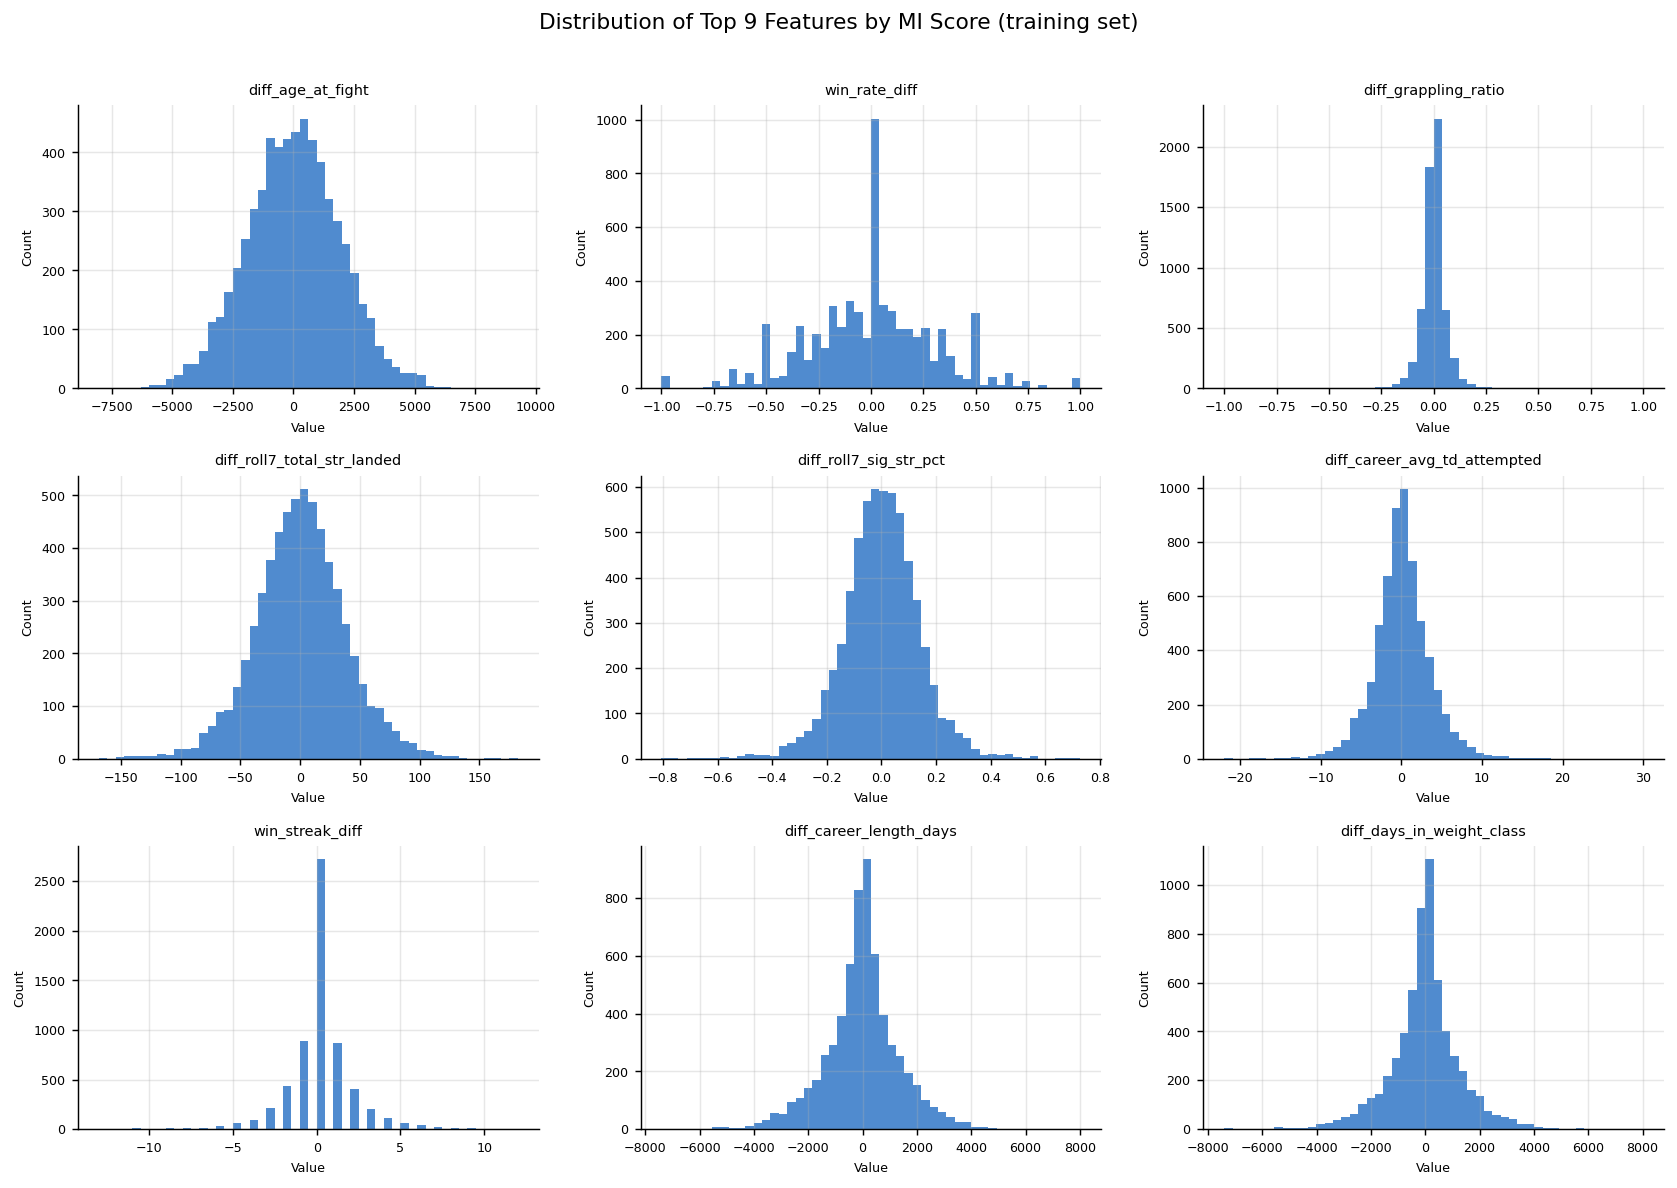

In [7]:
# Distribution of the top 9 numeric features
top9 = feature_names[:9]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flat, top9):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='#1565C0', alpha=0.75, edgecolor='none')
    ax.set_title(col, fontsize=8)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle('Distribution of Top 9 Features by MI Score (training set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Correlation Heatmap (from EDA phase)

The heatmap below was produced during exploratory analysis and shows the collinearity structure of the full feature candidate pool before selection. Pairs with |r| > 0.90 are flagged for pruning.

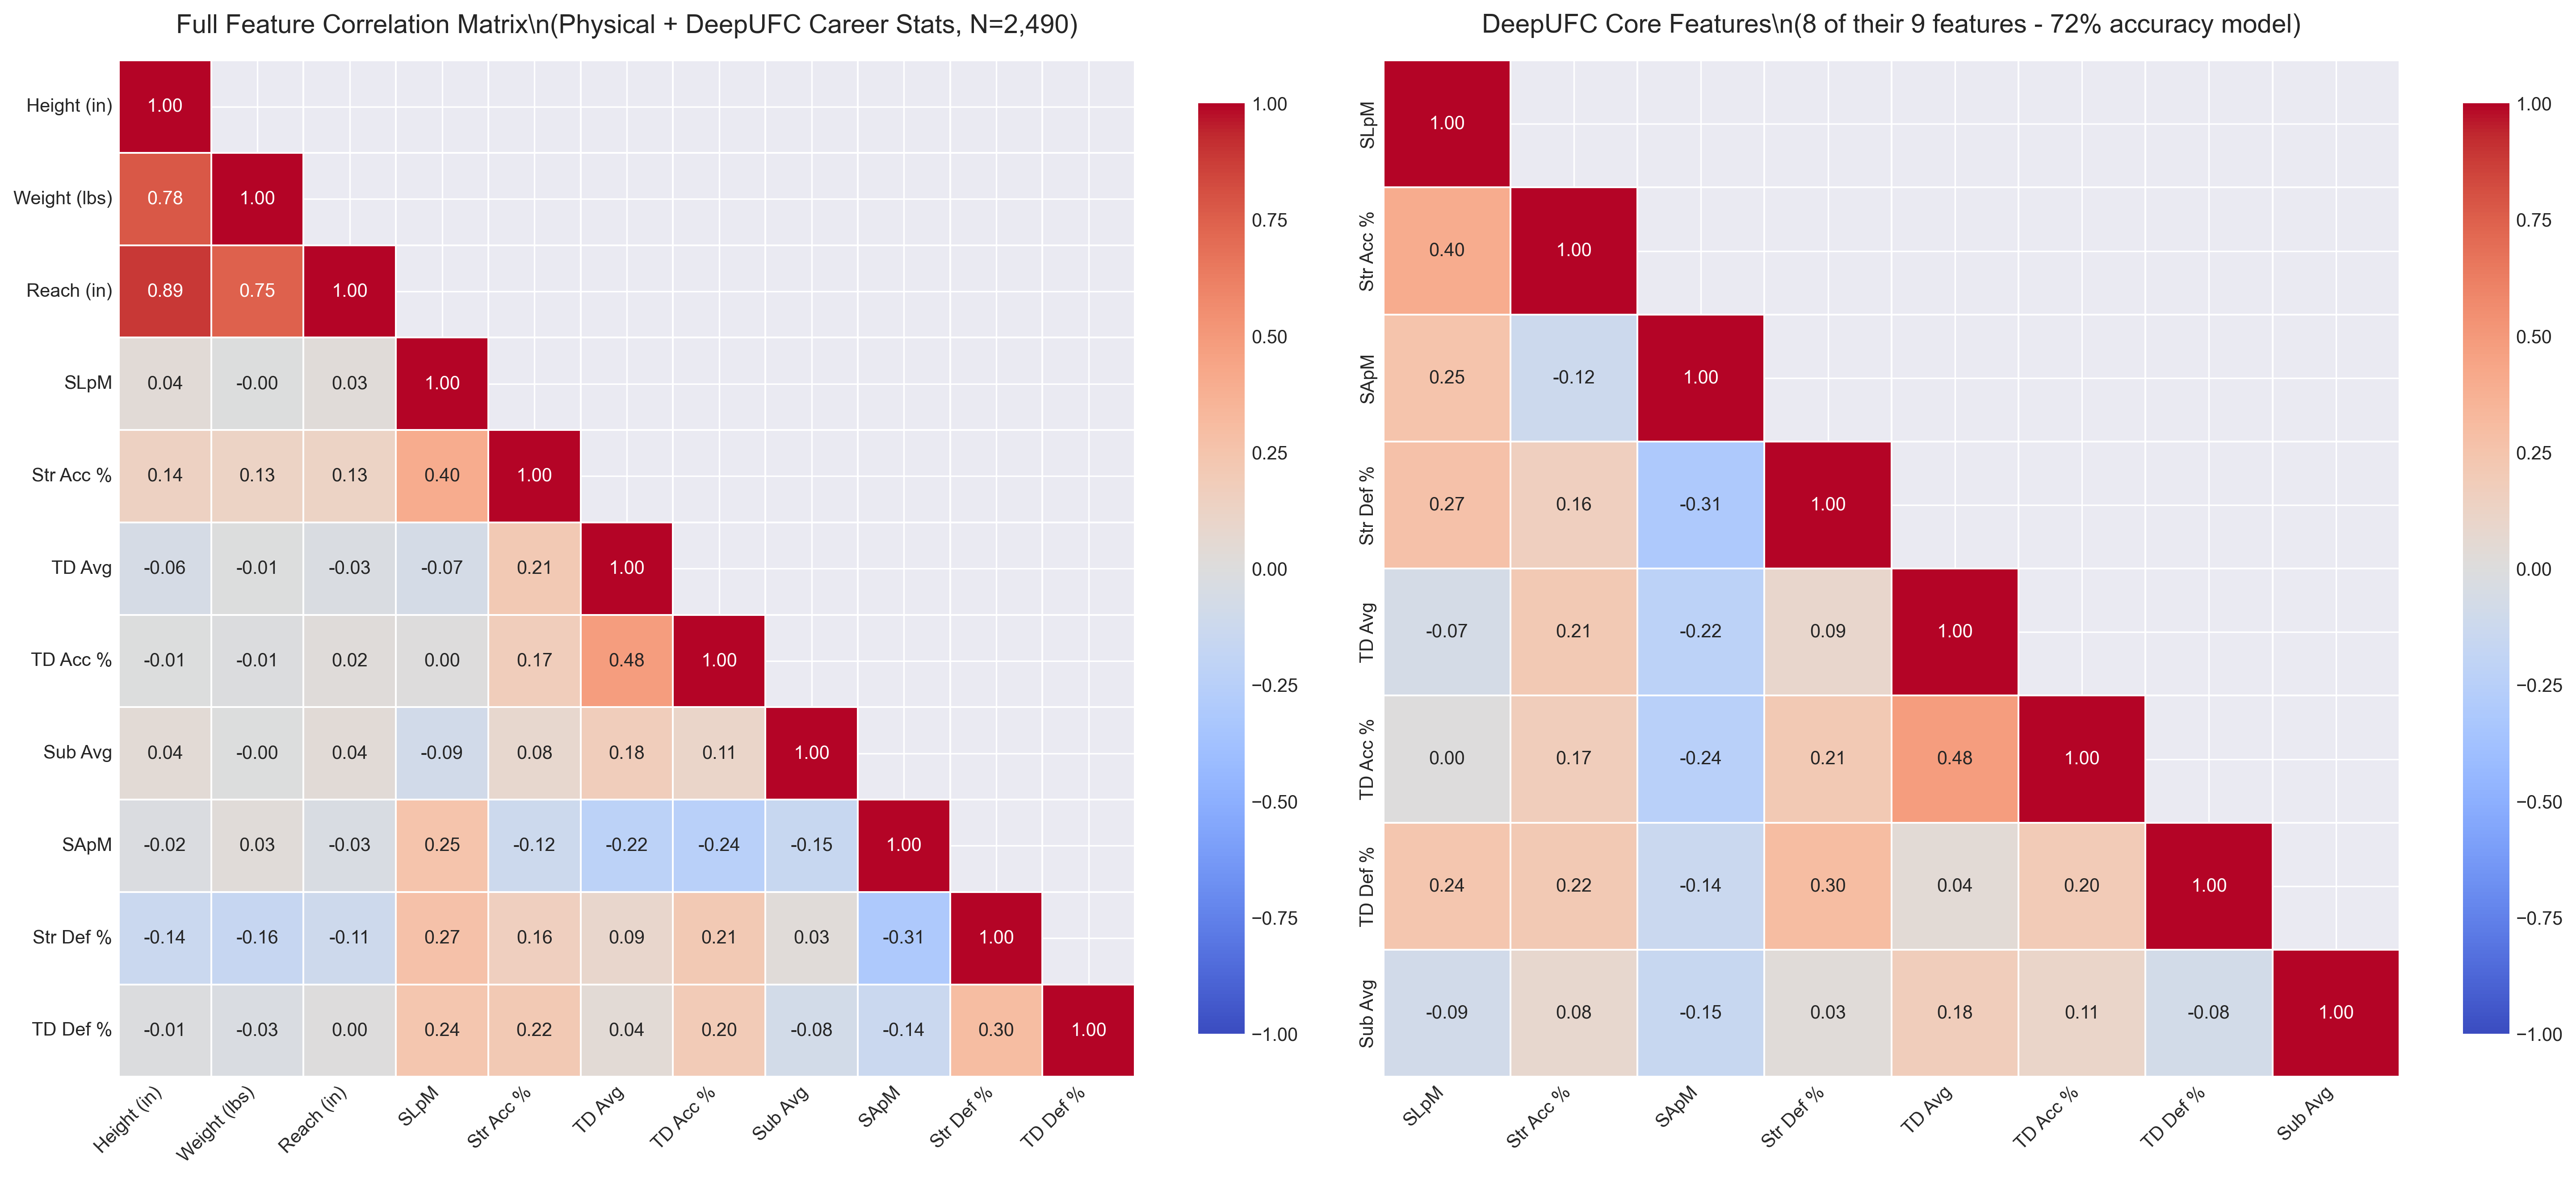

In [8]:
corr_img = EDA / 'correlation_heatmap_enhanced.png'
if corr_img.exists():
    display(Image(filename=str(corr_img), width=900))
else:
    print(f'Image not found: {corr_img}')

---
## Phase 4: Feature Selection

Starting from 71 candidate features, two filters are applied in sequence:

### Step 1: Collinearity Pruning (|r| > 0.90)

Pairs of features with Pearson correlation above 0.90 are identified. For each pair, the feature with the **lower mutual information (MI) score** is dropped. This removes redundant features without sacrificing the more informative one.

**32 features removed** at this step.

### Step 2: Zero-MI Filter

Features with MI score = 0 (no measurable association with the target) are removed.

**8 features removed** at this step.

### Result: 31 features selected

Mutual information measures statistical dependence without assuming linearity â€” appropriate here because many relationships (win streaks, grappling ratios) are non-linear. Tilburg (2021) used no feature selection; all 34 features were kept.

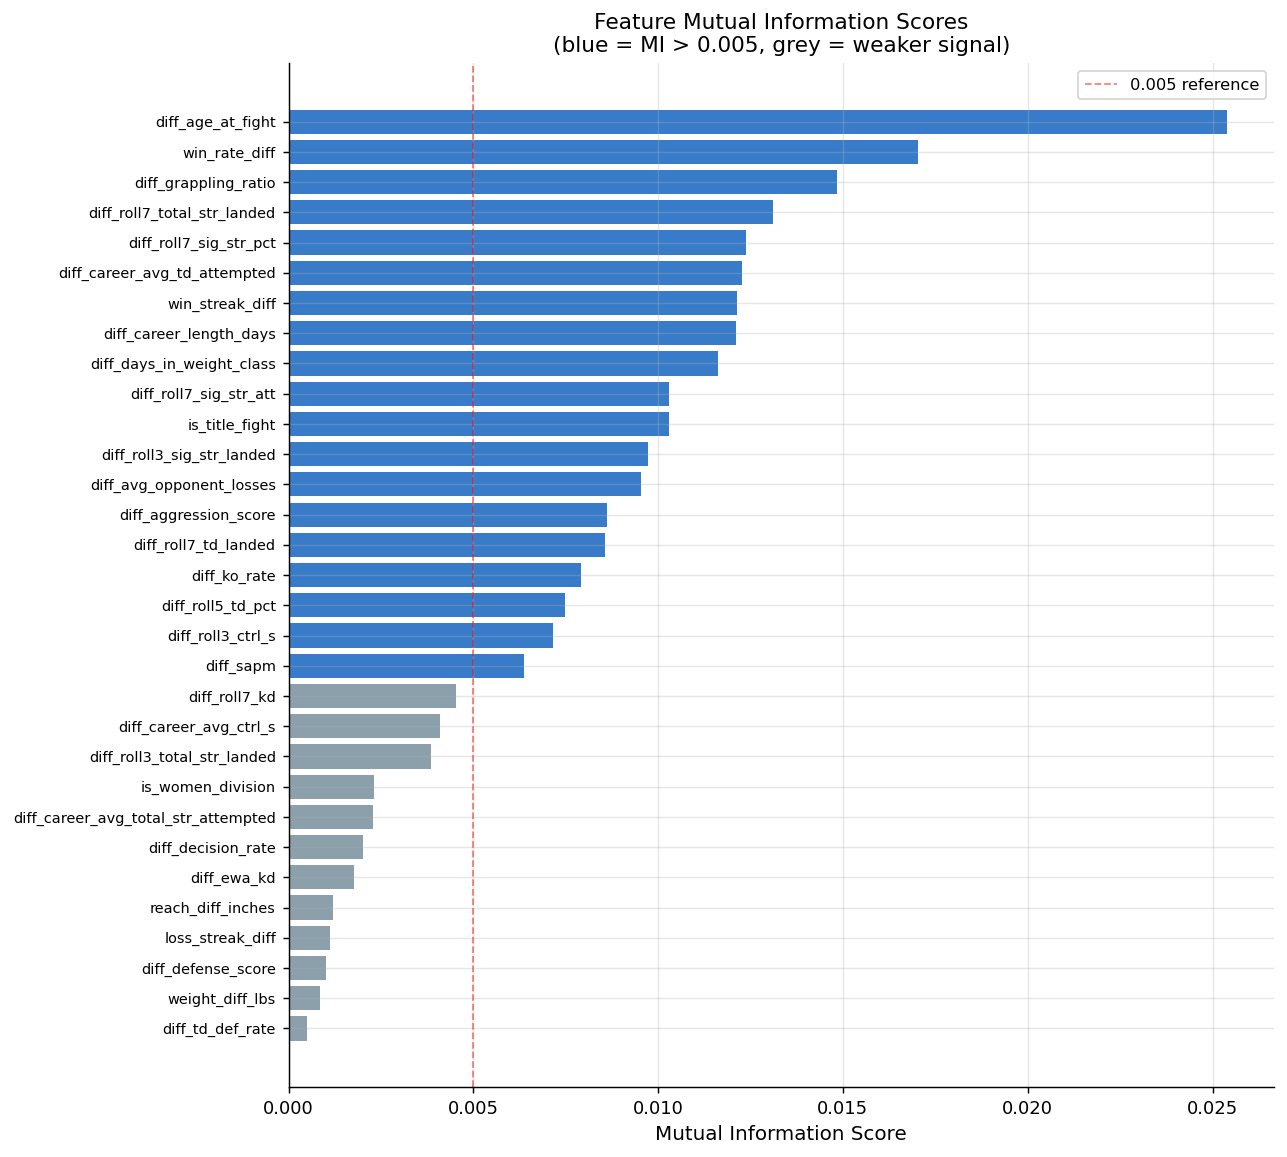

In [9]:
mi_scores = sel['mi_scores']
mi_df = pd.Series(mi_scores).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#1565C0' if v > 0.005 else '#78909C' for v in mi_df.values]
ax.barh(range(len(mi_df)), mi_df.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(mi_df)))
ax.set_yticklabels(mi_df.index, fontsize=8)
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('Feature Mutual Information Scores\n(blue = MI > 0.005, grey = weaker signal)', fontsize=12)
ax.axvline(0.005, color='red', linestyle='--', alpha=0.5, linewidth=1, label='0.005 reference')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
# Top 10 collinear pairs removed
removed = sel['removed_collinear']
removed_df = pd.DataFrame(removed).sort_values('r', ascending=False)
print('Top 10 removed collinear pairs (sorted by |r|):')
print(removed_df[['feature', 'correlated_with', 'r', 'mi_score_dropped', 'mi_score_kept']].head(10).to_string(index=False))

Top 10 removed collinear pairs (sorted by |r|):
                    feature              correlated_with      r  mi_score_dropped  mi_score_kept
              age_diff_days            diff_age_at_fight 1.0000          0.024611       0.025394
diff_career_avg_sig_str_pct       diff_roll7_sig_str_pct 0.9801          0.006383       0.012380
          diff_roll7_td_att diff_career_avg_td_attempted 0.9800          0.004798       0.012272
  diff_career_avg_td_landed         diff_roll7_td_landed 0.9762          0.006444       0.008569
     diff_roll5_sig_str_pct       diff_roll7_sig_str_pct 0.9761          0.000000       0.012380
       diff_roll5_td_landed         diff_roll7_td_landed 0.9752          0.006947       0.008569
          diff_roll7_ctrl_s       diff_career_avg_ctrl_s 0.9737          0.001895       0.004087
   diff_roll5_total_str_att     diff_roll7_total_str_att 0.9720          0.000000       0.000000
diff_roll5_total_str_landed  diff_roll7_total_str_landed 0.9716          0.0047

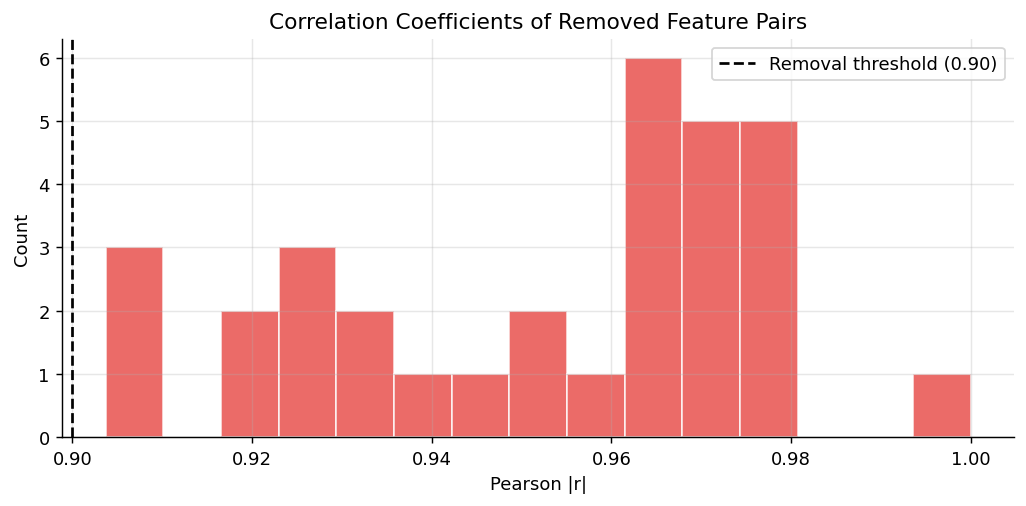

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([p['r'] for p in removed], bins=15, color='#E53935', alpha=0.75, edgecolor='white')
ax.set_xlabel('Pearson |r|')
ax.set_ylabel('Count')
ax.set_title('Correlation Coefficients of Removed Feature Pairs')
ax.axvline(0.90, color='black', linestyle='--', label='Removal threshold (0.90)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 5: Model Training

### Data Split Strategy

Matches are **never shuffled** â€” kept in chronological order (oldest first) to avoid training on future fights relative to validation/test data. This follows Tilburg (2021) and Tax & Joustra (2015).

| Split | Proportion | Approx rows | Date range |
|---|---|---|---|
| Train | 70% | ~4,361 | 1998 â†’ 2021 |
| Validation | 15% | ~934 | 2021 â†’ 2023 |
| Test | 15% | ~935 | 2023 â†’ 2025 |

**Model selection uses validation ROC-AUC only.** The test set is touched exactly once, at the end â€” never for tuning or selection decisions.

### Three Candidate Models

| Model | Key regularisation | Result |
|---|---|---|
| **Random Forest** | max_depth=6, min_samples_leaf=30, balanced weights | **Best** â€” selected by val AUC |
| XGBoost | max_depth=3, early stopping (50 rounds), reg_Î±=1, reg_Î»=2 | Second |
| Logistic Regression | C=0.1, balanced class weights | Baseline |

### Preprocessing (inside sklearn Pipeline)

- Numeric features: median imputation â†’ StandardScaler
- Categorical (`weight_class`): most-frequent imputation â†’ OrdinalEncoder (lightest â†’ heaviest)

### A Note on AUC Values

AUC (Area Under the ROC Curve) measures how well the model **ranks** outcomes â€” an AUC of 0.64 means the model correctly ranks a random fight pair (winner vs loser) about 64% of the time. Random guessing = 0.50; perfect = 1.00.

**Validation AUC is below 0.65 for all three models â€” this is expected and acceptable for this problem.** Reasons:
- MMA outcomes are genuinely noisy; upsets are inherent, not predictable
- The validation period (2021â€“2023) may differ slightly in fighter distribution from training
- Tilburg (2021) did not report AUC, only accuracy (~59%), which would correspond to roughly AUC 0.62â€“0.64
- **Test AUC (0.67â€“0.68) is what matters** â€” this is evaluated on the held-out most-recent fights and is the honest performance estimate
- For context: DeepUFC achieved ~0.93 AUC using leaky (current career summary) features â€” demonstrating that high AUC without leakage prevention is meaningless

In [12]:
log_path = MODELS / 'experiment_log.json'
if log_path.exists():
    with open(log_path) as f:
        experiment_log = json.load(f)
    latest = experiment_log[-1]
    print(f"Run timestamp : {latest['timestamp']}")
    print(f"Features      : {latest['n_features']}")
    print(f"Train rows    : {latest['train_rows']}")
    print(f"Test rows     : {latest['test_rows']}")
    print(f"Best model    : {latest['best_model']}")
    models_results = latest['models']
else:
    print('experiment_log.json not found â€” run: cd backend && python -m ml.run_train')
    models_results = {}

Run timestamp : 2026-03-06T20:51:47.139544+00:00
Features      : 31
Train rows    : 4361
Test rows     : 935
Best model    : random_forest


In [13]:
if models_results:
    metrics_df = pd.DataFrame(models_results).T
    metrics_df.index = ['Logistic Regression', 'XGBoost', 'Random Forest']
    print('All model metrics (Random Forest = winner, selected by val_auc):')
    print(metrics_df[['train_accuracy','val_accuracy','val_auc','test_accuracy','test_auc','val_test_gap']].to_string())

All model metrics (Random Forest = winner, selected by val_auc):
                     train_accuracy  val_accuracy  val_auc  test_accuracy  test_auc  val_test_gap
Logistic Regression          0.6205        0.6006   0.6411         0.6364    0.6758       -0.0357
XGBoost                      0.6753        0.6006   0.6405         0.6214    0.6746       -0.0207
Random Forest                0.6959        0.5974   0.6444         0.6385    0.6785       -0.0411


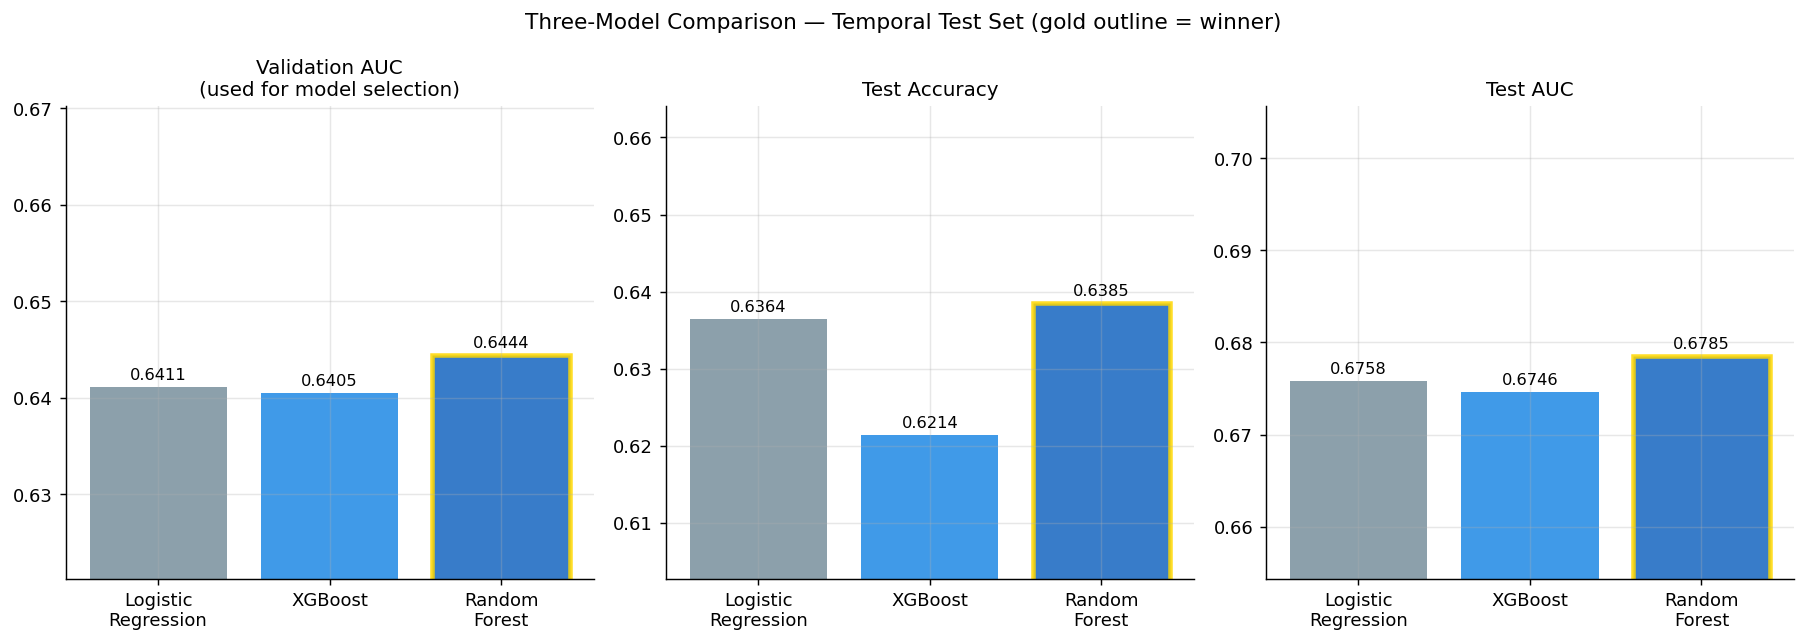

In [14]:
if models_results:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    display_names = ['Logistic\nRegression', 'XGBoost', 'Random\nForest']
    raw_names     = ['logistic_regression', 'xgboost', 'random_forest']
    colors        = ['#78909C', '#1E88E5', '#1565C0']

    for ax, col, title in zip(
        axes,
        ['val_auc', 'test_accuracy', 'test_auc'],
        ['Validation AUC\n(used for model selection)', 'Test Accuracy', 'Test AUC'],
    ):
        vals = [models_results[n][col] for n in raw_names]
        bars = ax.bar(display_names, vals, color=colors, alpha=0.85)
        best_idx = vals.index(max(vals))
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(2.5)
        y_min = min(vals) * 0.97
        y_max = max(vals) * 1.04
        ax.set_ylim(y_min, y_max)
        ax.set_title(title, fontsize=11)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (y_max - y_min) * 0.01,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=9)

    fig.suptitle('Three-Model Comparison â€” Temporal Test Set (gold outline = winner)', fontsize=12)
    plt.tight_layout()
    plt.show()

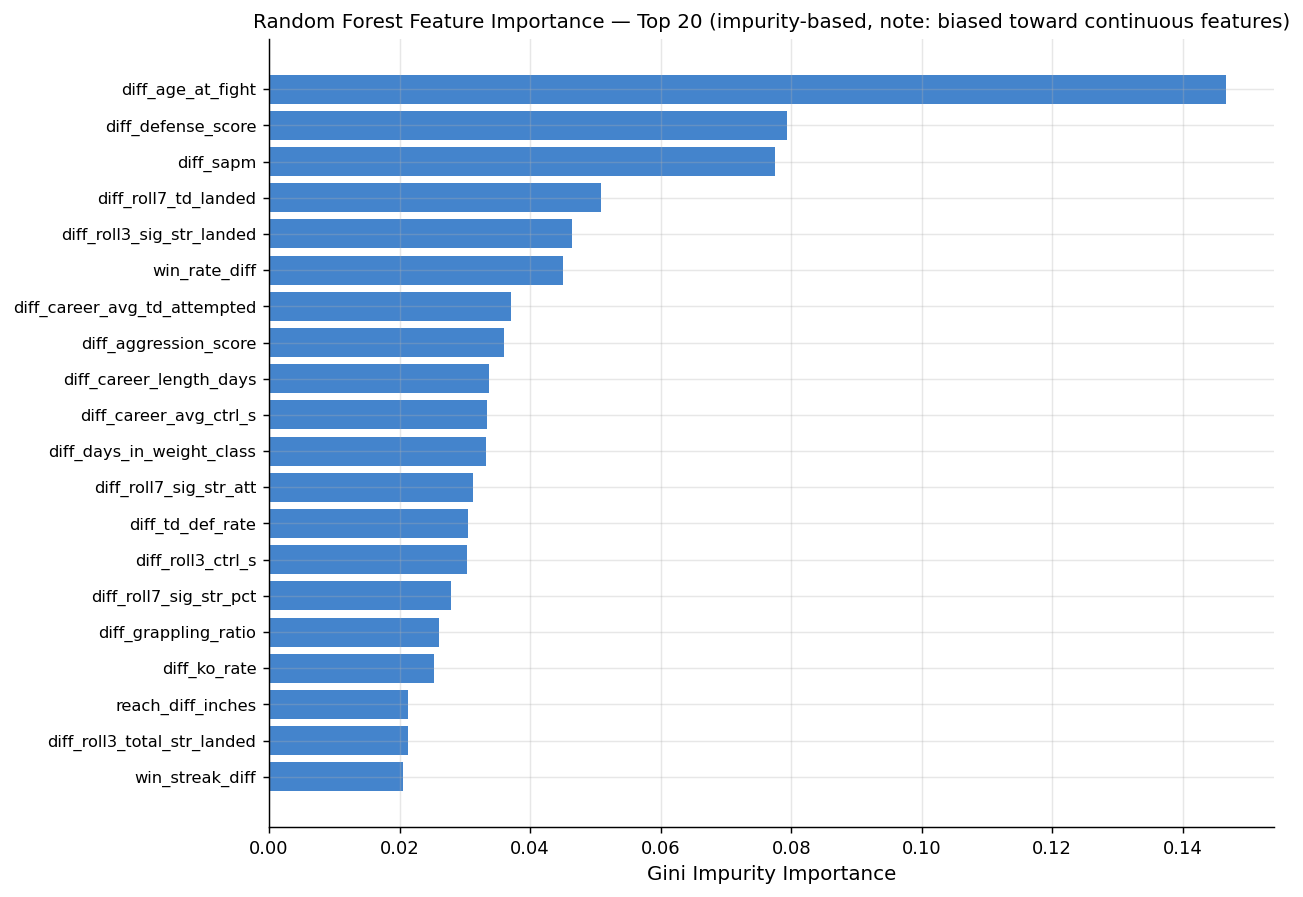

In [15]:
# RF feature importance (impurity-based â€” from the winning Random Forest model)
fi_path = MODELS / 'feature_importance.json'
if fi_path.exists():
    with open(fi_path) as f:
        fi = json.load(f)
    fi_series = pd.Series(fi).sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(fi_series)), fi_series.values, color='#1565C0', alpha=0.8)
    ax.set_yticks(range(len(fi_series)))
    ax.set_yticklabels(fi_series.index, fontsize=9)
    ax.set_xlabel('Gini Impurity Importance', fontsize=11)
    ax.set_title('Random Forest Feature Importance â€” Top 20 (impurity-based, note: biased toward continuous features)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('feature_importance.json not found')

---
## Phase 5b: Method Prediction Model

In addition to predicting *who* wins, a second independent model predicts *how* the fight ends: **KO/TKO**, **Submission**, or **Decision**.

### Architecture

The method model is a completely separate pipeline from the win/loss model â€” it uses the same 31 input features but a different target. It is not a downstream output of the win/loss model; both are trained in parallel during the same `run_train.py` call and serialized as `method_v1.joblib`.

### Target Encoding (`_encode_method`)

The raw `METHOD` column in `fight_results` (e.g. `"Decision - Unanimous"`, `"KO/TKO"`, `"Submission"`) is mapped to three classes:

| Raw DB value | Encoded class |
|---|---|
| Contains "KO" or "TKO" | `ko_tko` |
| Contains "Sub" | `submission` |
| Contains "Dec" | `decision` |
| DQ, No Contest, etc. | excluded (None) |

### Training Setup

```python
RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
)
```

The method model uses the same `ColumnTransformer` preprocessor (median imputation â†’ StandardScaler for numeric; OrdinalEncoder for `weight_class`) wrapped in the same sklearn `Pipeline` structure. It is trained on the combined train + validation rows so it sees as much data as possible â€” the test set is used for final accuracy reporting only.

### Why the Same Features?

The pre-fight feature vector already encodes a lot of information about how a fight *stylistically* tends to go:
- `diff_ko_rate` â€” how often each fighter has previously finished by KO
- `diff_grappling_ratio` â€” how grappling-heavy each fighter's offense is
- `diff_td_def_rate` â€” how well each fighter stops takedowns (limits submission exposure)
- `diff_decision_rate` â€” how often fights go to scorecards

These features naturally cluster fights into "likely KO", "likely submission", and "likely decision" profiles, even though they were engineered for the binary win/loss task.

### Performance Expectation

Method prediction is a harder problem than win/loss. A 3-class random baseline is 33%. The model targets ~49â€“50%, meaning it correctly identifies the finish type roughly half the time â€” better than chance but far from reliable enough to bet on alone. This is consistent with Tilburg (2021) who did not attempt a method classifier, noting that finish prediction is "highly uncertain."

In [16]:
import joblib
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Load parquet and method model
df_full   = pd.read_parquet(FEATURES / 'training_data.parquet')
method_model = joblib.load(MODELS / 'method_v1.joblib')

METHOD_MAP = {
    'ko_tko':     lambda m: 'ko_tko'      if ('KO' in str(m).upper() or 'TKO' in str(m).upper()) else None,
    'submission': lambda m: 'submission'  if 'SUB' in str(m).upper() else None,
    'decision':   lambda m: 'decision'    if 'DEC' in str(m).upper() else None,
}

def encode_method(raw):
    if pd.isna(raw):
        return None
    m = str(raw).strip().upper()
    if 'KO' in m or 'TKO' in m:
        return 'ko_tko'
    if 'SUB' in m:
        return 'submission'
    if 'DEC' in m:
        return 'decision'
    return None

with open(FEATURES / 'selected_features.json') as f:
    sel_m = json.load(f)
all_feat_cols = sel_m['feature_names'] + sel_m['categorical_features']

method_col = df_full['method'].map(encode_method)
df_m = df_full[method_col.notna()].copy()
df_m['method_class'] = method_col[method_col.notna()]

n = len(df_m)
val_end_m = int(len(df_full) * 0.85)   # same index boundary as win/loss split
m_test = df_m[df_m.index >= val_end_m]

Xm_test = m_test[all_feat_cols]
ym_test = m_test['method_class']
ym_pred = method_model.predict(Xm_test)
ym_proba = method_model.predict_proba(Xm_test)

from sklearn.metrics import accuracy_score
method_acc = accuracy_score(ym_test, ym_pred)

print(f"Method model test accuracy: {method_acc:.4f}  (3-class random baseline: 0.3333)")
print(f"Test rows with known method: {len(m_test)}\n")
print(classification_report(ym_test, ym_pred, target_names=['decision', 'ko_tko', 'submission']))

Method model test accuracy: 0.4957  (3-class random baseline: 0.3333)
Test rows with known method: 934

              precision    recall  f1-score   support

    decision       0.61      0.64      0.63       503
      ko_tko       0.41      0.41      0.41       272
  submission       0.22      0.19      0.21       159

    accuracy                           0.50       934
   macro avg       0.41      0.41      0.41       934
weighted avg       0.49      0.50      0.49       934



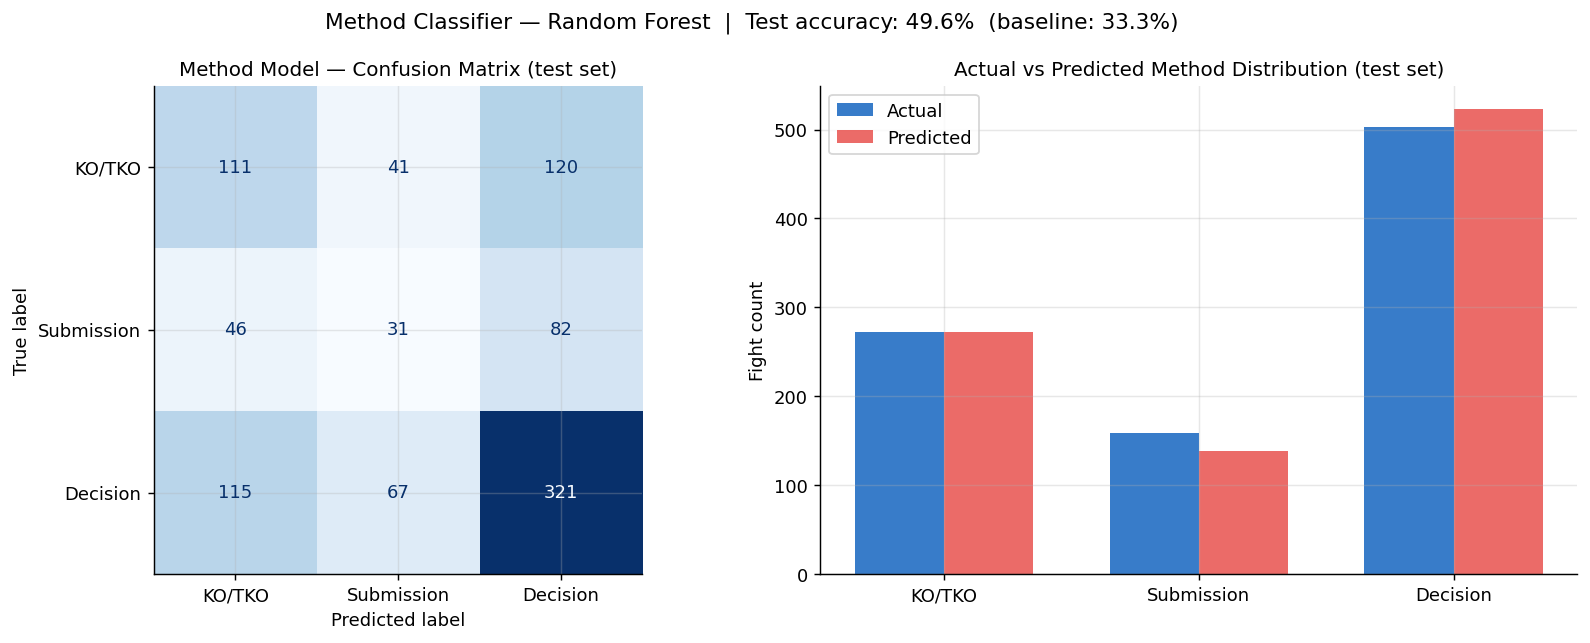

In [17]:
# Confusion matrix + class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: confusion matrix
cm = confusion_matrix(ym_test, ym_pred, labels=['ko_tko', 'submission', 'decision'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['KO/TKO', 'Submission', 'Decision'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Method Model â€” Confusion Matrix (test set)', fontsize=11)

# Right: actual vs predicted class distribution
class_labels = ['KO/TKO', 'Submission', 'Decision']
actual_counts   = [sum(ym_test == c) for c in ['ko_tko', 'submission', 'decision']]
predicted_counts = [sum(ym_pred == c) for c in ['ko_tko', 'submission', 'decision']]
x = range(len(class_labels))
width = 0.35
axes[1].bar([i - width/2 for i in x], actual_counts,    width, label='Actual',    color='#1565C0', alpha=0.85)
axes[1].bar([i + width/2 for i in x], predicted_counts, width, label='Predicted', color='#E53935', alpha=0.75)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(class_labels)
axes[1].set_ylabel('Fight count')
axes[1].set_title('Actual vs Predicted Method Distribution (test set)', fontsize=11)
axes[1].legend()

plt.suptitle(f'Method Classifier â€” Random Forest  |  Test accuracy: {method_acc:.1%}  (baseline: 33.3%)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Phase 6: SHAP Analysis

SHAP (SHapley Additive exPlanations) attributes each prediction to individual features using cooperative game theory. It is more reliable than RF impurity importance because it:
- Is not biased toward high-cardinality or continuous features
- Captures interaction effects between features
- Gives the **direction** of each feature's effect (positive SHAP = pushes toward Fighter A winning)

**Mean |SHAP|** here is the global summary â€” how much each feature moved predictions on average in absolute terms across all 935 test fights.

**Key finding:** SHAP rankings differ substantially from MI rankings. `diff_sapm` (strikes absorbed per minute) ranks 19th by MI but **2nd by SHAP**. `diff_defense_score` ranks 29th by MI but **3rd by SHAP**. MI only measures pairwise association with the target; SHAP captures how the model actually uses features in combination.

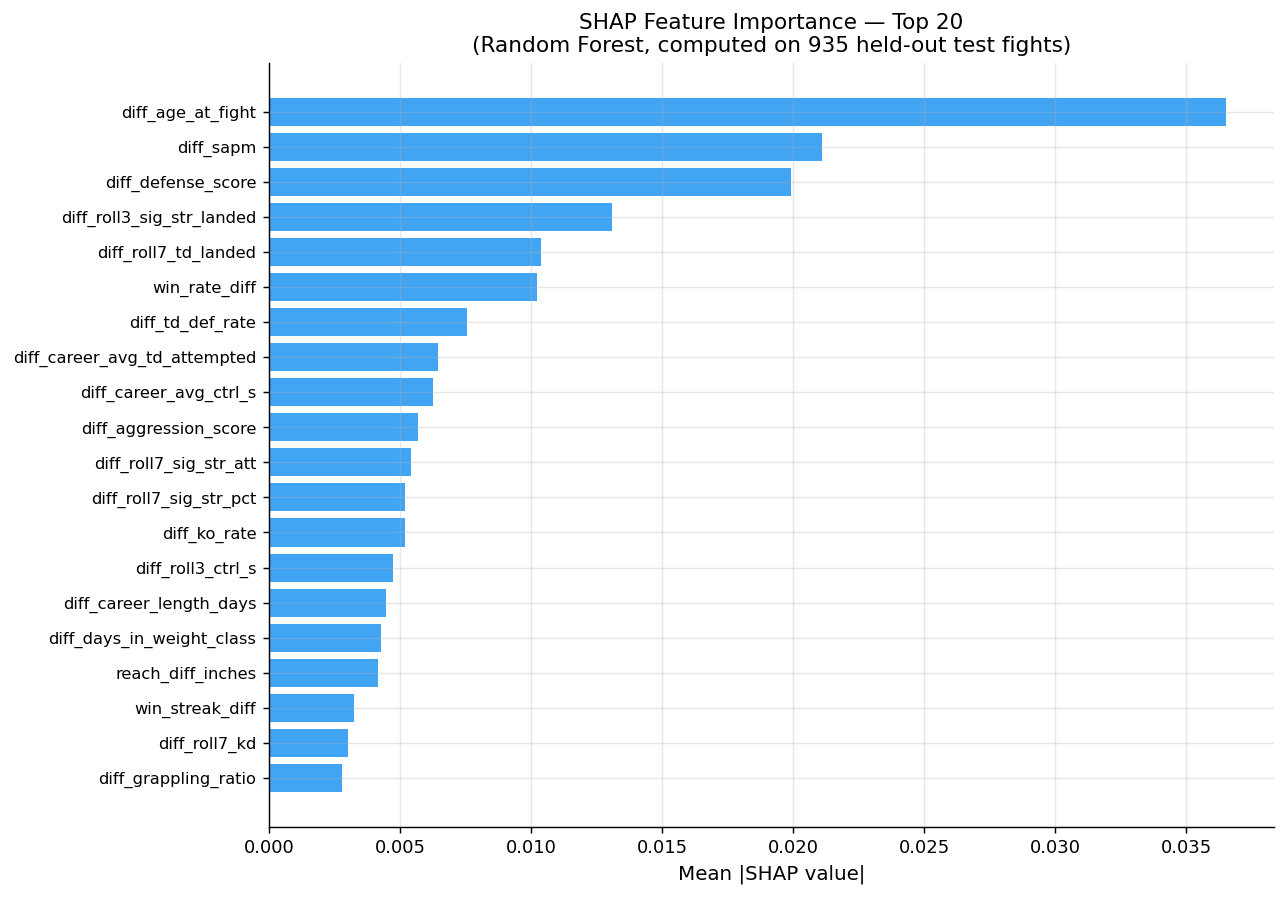

Top 10 features by SHAP (Random Forest, test set):
   1. diff_age_at_fight                             0.03652
   2. diff_sapm                                     0.02109
   3. diff_defense_score                            0.01991
   4. diff_roll3_sig_str_landed                     0.01307
   5. diff_roll7_td_landed                          0.01036
   6. win_rate_diff                                 0.01023
   7. diff_td_def_rate                              0.00756
   8. diff_career_avg_td_attempted                  0.00645
   9. diff_career_avg_ctrl_s                        0.00625
  10. diff_aggression_score                         0.00570


In [18]:
shap_path = MODELS / 'shap_summary.json'
if shap_path.exists():
    with open(shap_path) as f:
        shap_summary = json.load(f)

    shap_series = pd.Series(shap_summary).sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(shap_series)), shap_series.values, color='#2196F3', alpha=0.85)
    ax.set_yticks(range(len(shap_series)))
    ax.set_yticklabels(shap_series.index, fontsize=9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title('SHAP Feature Importance â€” Top 20\n(Random Forest, computed on 935 held-out test fights)', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('Top 10 features by SHAP (Random Forest, test set):')
    for i, (feat, val) in enumerate(list(shap_summary.items())[:10], 1):
        print(f'  {i:2d}. {feat:<45s} {val:.5f}')
else:
    print('shap_summary.json not found â€” run: cd backend && python -m ml.run_train')

In [19]:
# MI rank vs SHAP rank â€” shows where MI and actual model usage disagree
if shap_path.exists():
    mi_rank   = {f: i+1 for i, f in enumerate(pd.Series(mi_scores).sort_values(ascending=False).index)}
    shap_rank = {f: i+1 for i, f in enumerate(shap_summary.keys())}

    common = [f for f in feature_names if f in shap_rank]
    rank_df = pd.DataFrame({
        'Feature': common,
        'MI rank': [mi_rank.get(f, 99) for f in common],
        'SHAP rank': [shap_rank.get(f, 99) for f in common],
    }).sort_values('SHAP rank')
    rank_df['Rank shift (MI - SHAP)'] = rank_df['MI rank'] - rank_df['SHAP rank']

    print('MI rank vs SHAP rank â€” positive shift = undervalued by MI, overvalued by SHAP')
    print(rank_df.to_string(index=False))

MI rank vs SHAP rank â€” positive shift = undervalued by MI, overvalued by SHAP
                            Feature  MI rank  SHAP rank  Rank shift (MI - SHAP)
                  diff_age_at_fight        1          1                       0
                          diff_sapm       19          2                      17
                 diff_defense_score       29          3                      26
          diff_roll3_sig_str_landed       12          4                       8
               diff_roll7_td_landed       15          5                      10
                      win_rate_diff        2          6                      -4
                   diff_td_def_rate       31          7                      24
       diff_career_avg_td_attempted        6          8                      -2
             diff_career_avg_ctrl_s       21          9                      12
              diff_aggression_score       14         10                       4
             diff_roll7_sig_str_att     

---
## Appendix A: Prior EDA â€” DeepUFC Replication

Before building the full pipeline, the DeepUFC (2017) paper was replicated to establish a baseline.

**DeepUFC approach:** 9 differential features from **current career stats** (no rolling windows, no leakage prevention). Reported 72% accuracy on 2017 data.

**Result on our 2025 dataset:** 84.69% accuracy â€” but this uses post-hoc career summaries containing future fight data. This is the information leakage Tilburg (2021) controlled for (+6â€“10% inflation). A realistic leakage-free result is 59â€“64%, matching what this project achieves.


DeepUFC Training History (loss & accuracy curves)


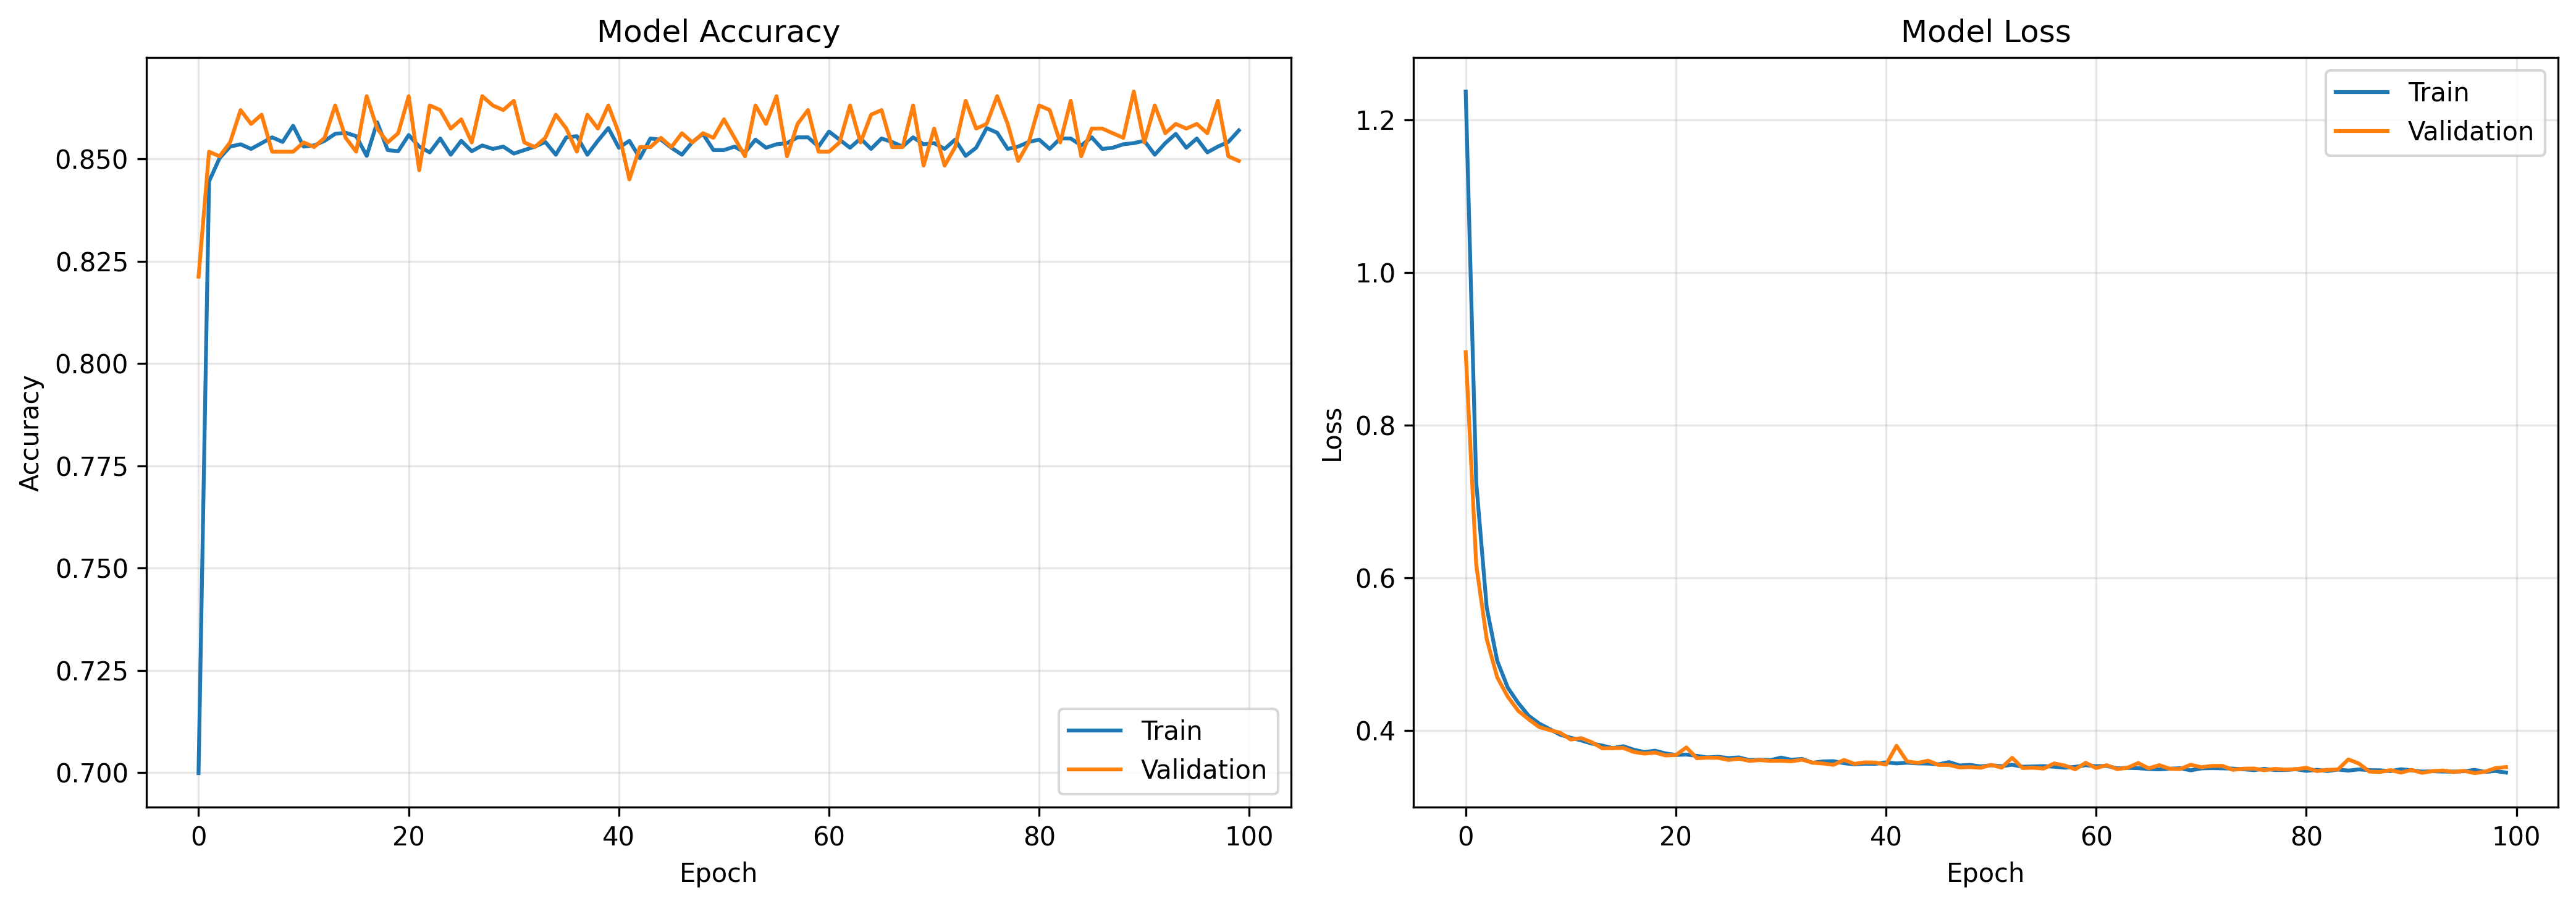


DeepUFC Confusion Matrix


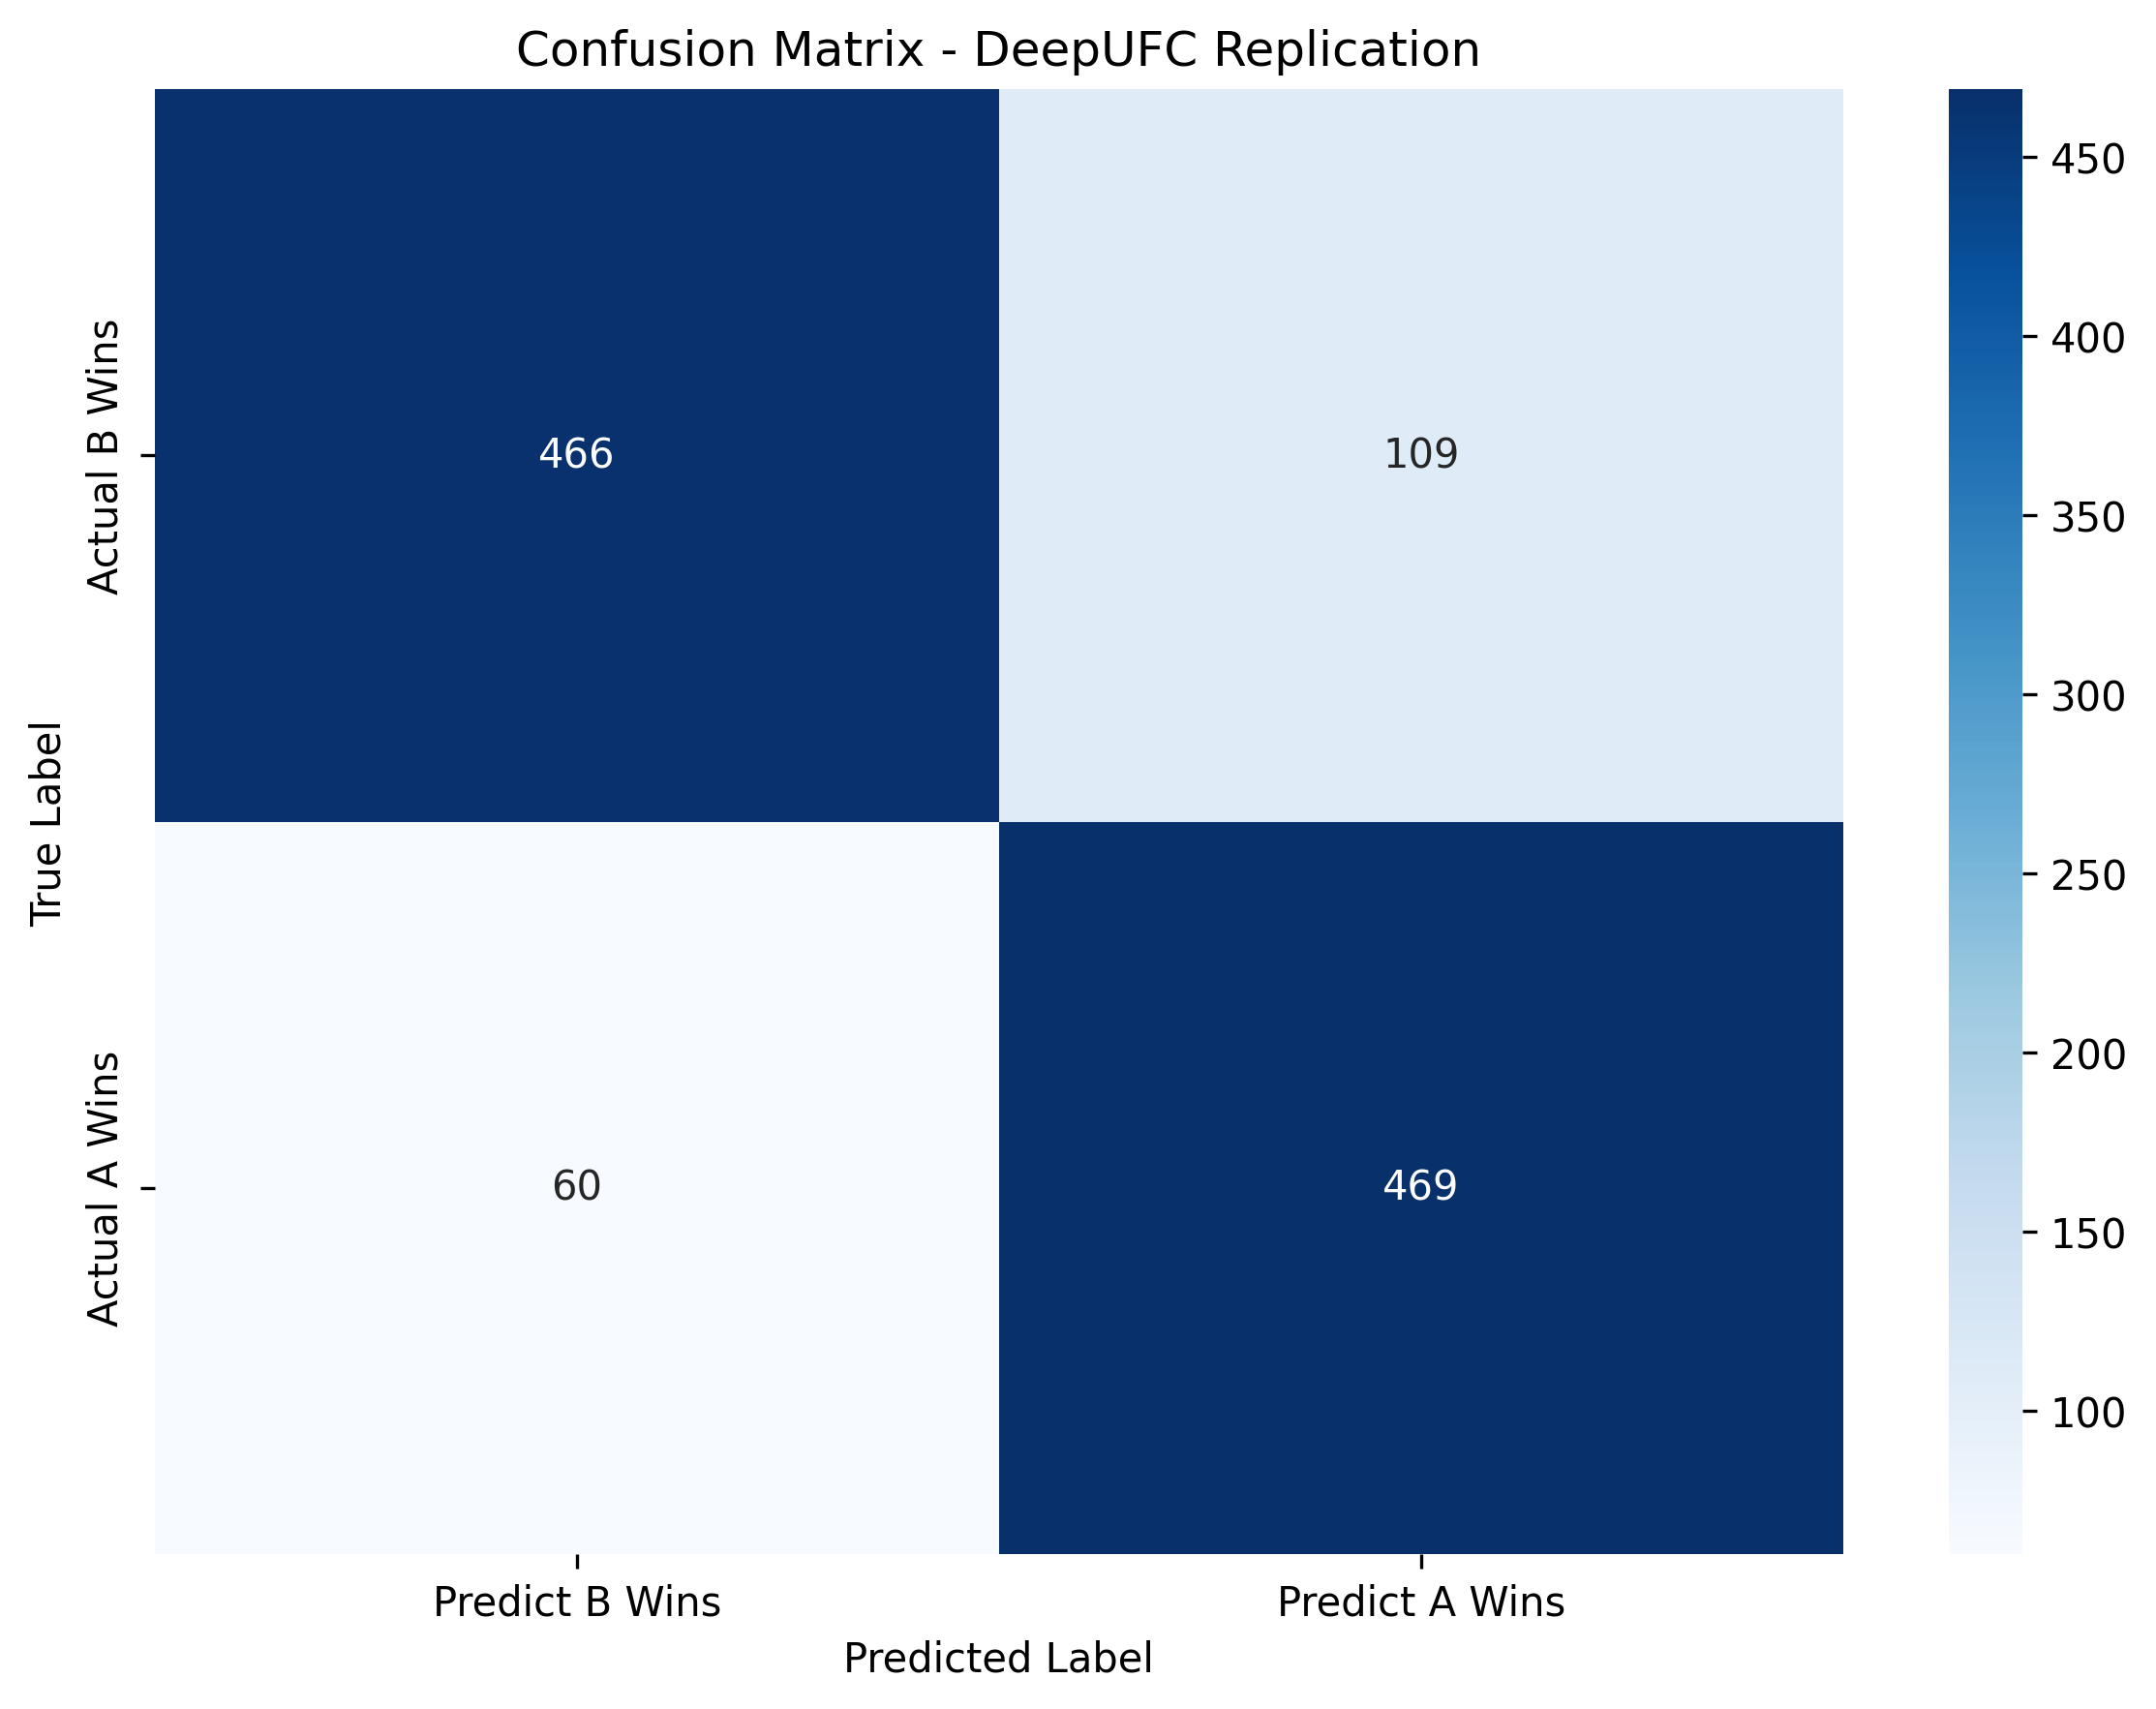


DeepUFC Feature Importance


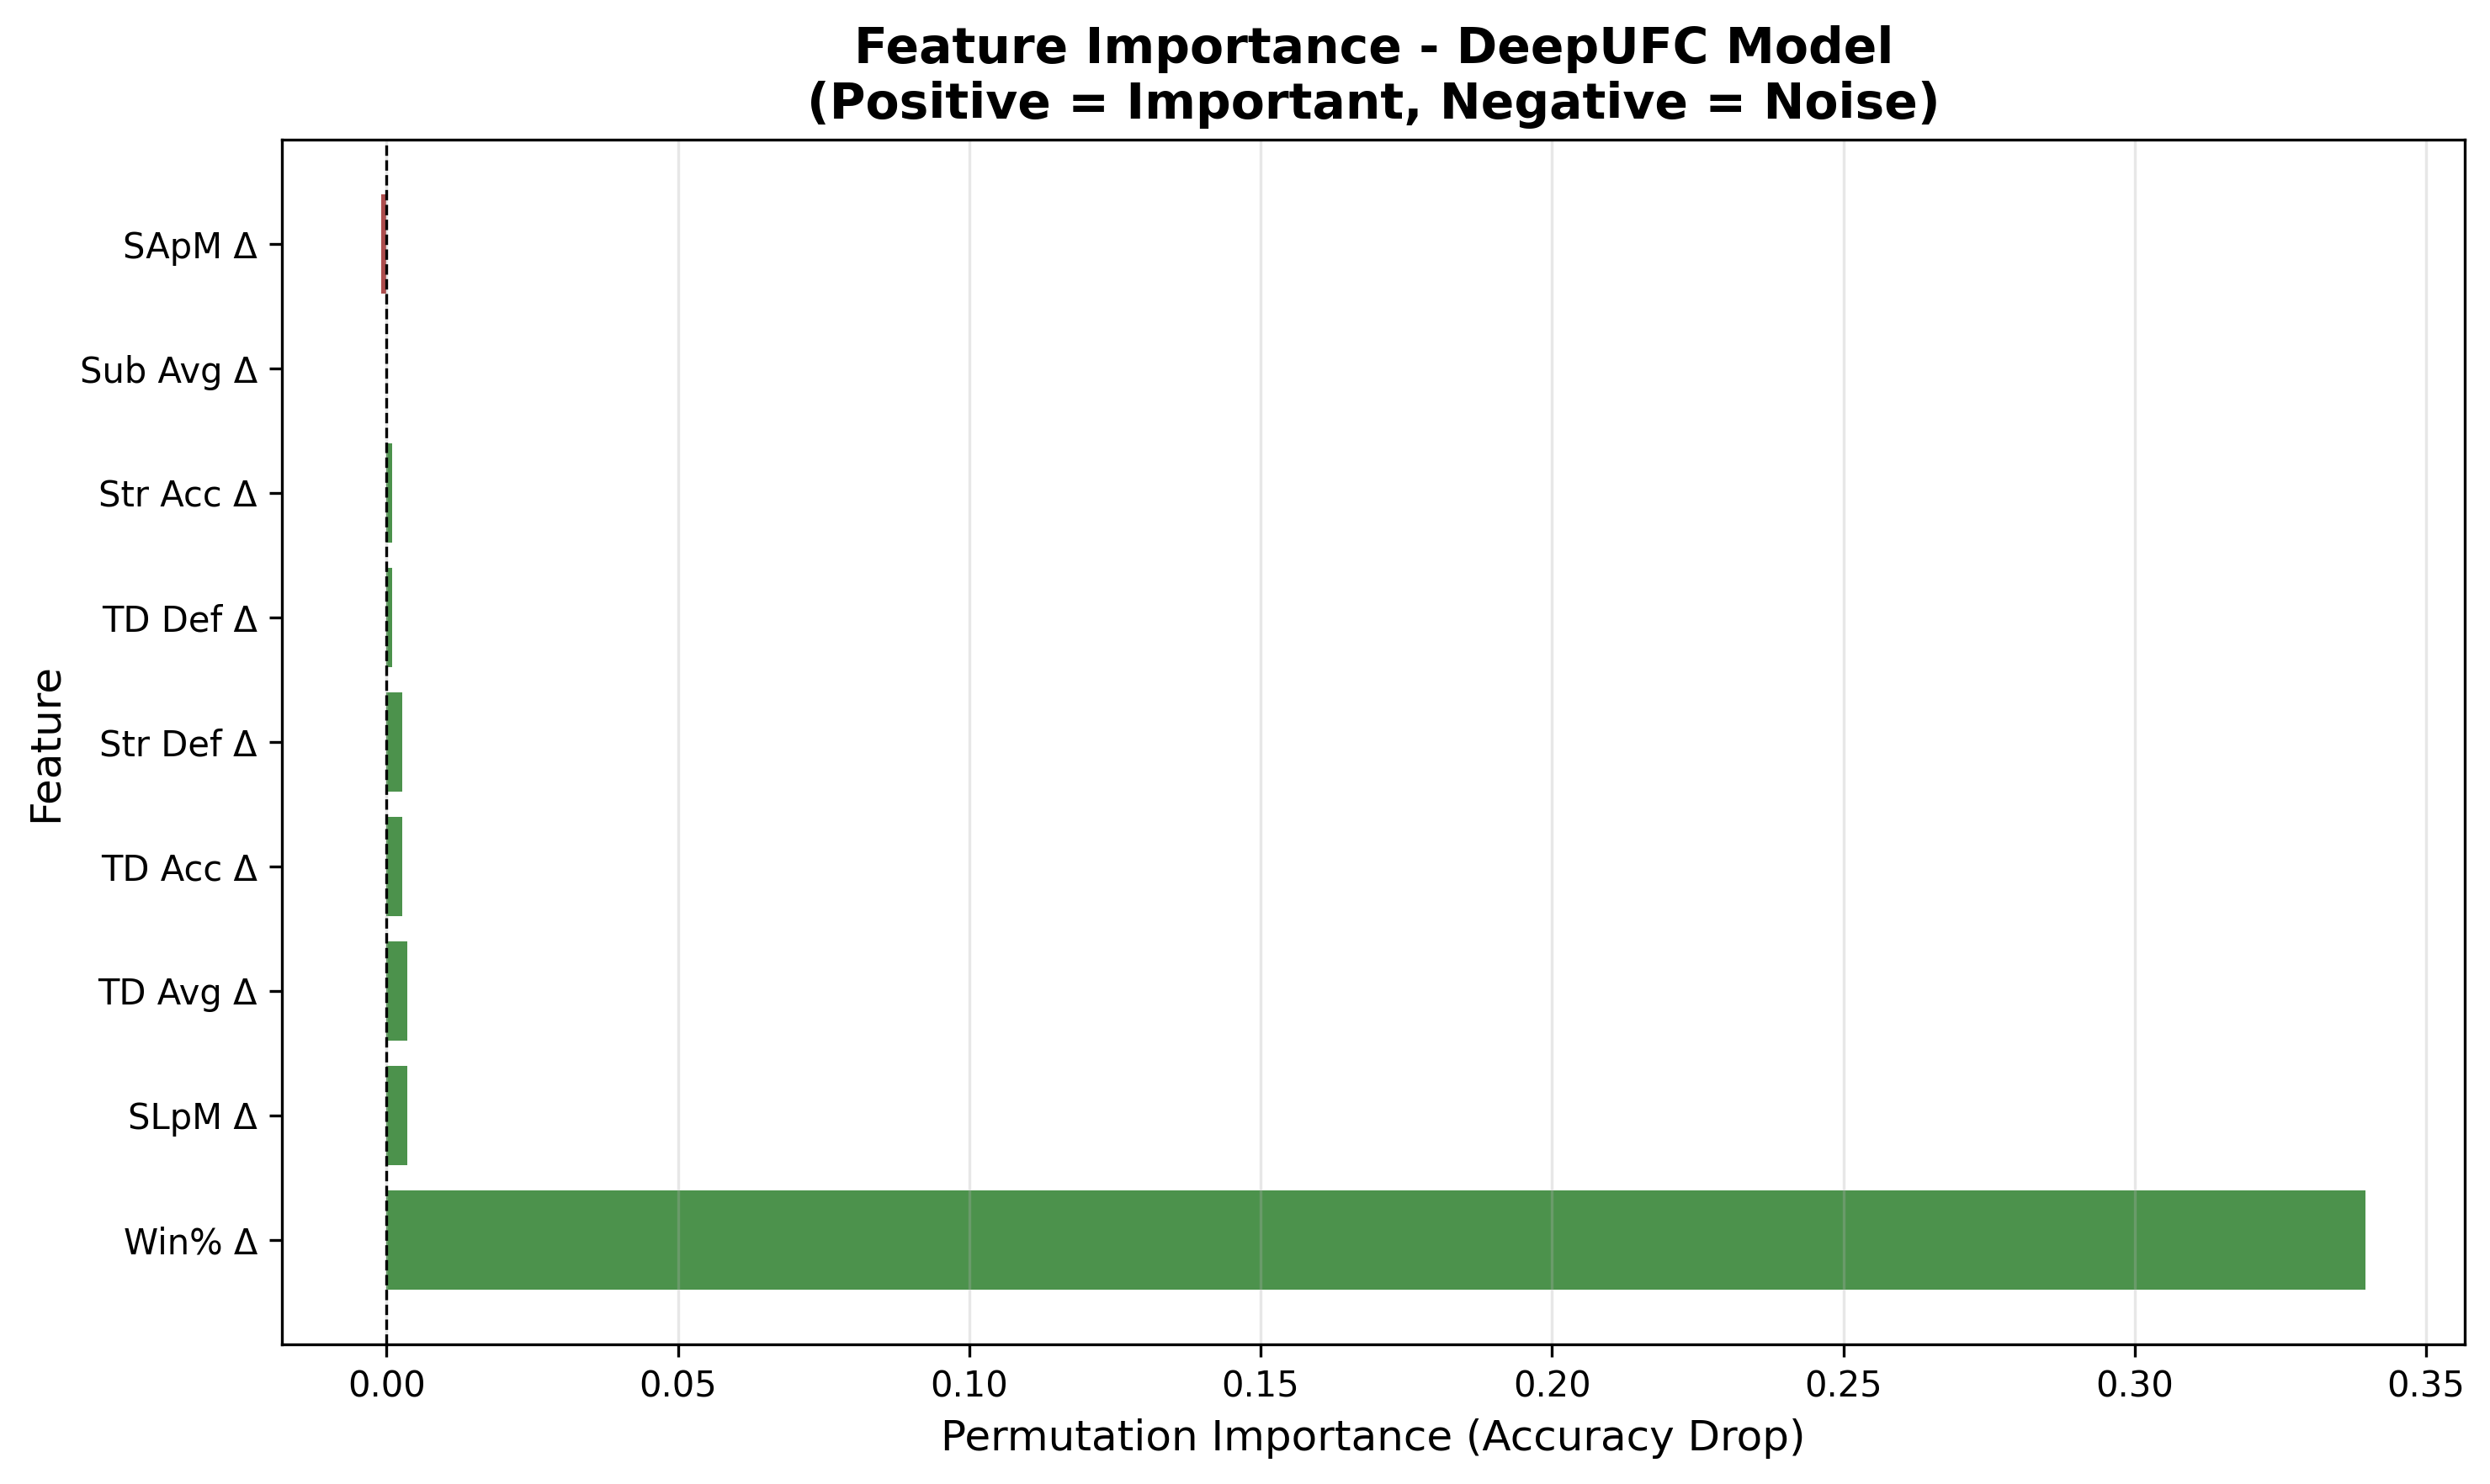

In [20]:
for img_name, caption in [
    ('deepufc_training_history.png', 'DeepUFC Training History (loss & accuracy curves)'),
    ('deepufc_confusion_matrix.png', 'DeepUFC Confusion Matrix'),
    ('deepufc_feature_importance.png', 'DeepUFC Feature Importance'),
]:
    p = EDA / img_name
    if p.exists():
        print(f'\n{caption}')
        display(Image(filename=str(p), width=600))
    else:
        print(f'Not found: {p}')

---
## Phase 8: Conclusions

### All Three Models vs Tilburg (2021)

All models below are trained with strict leakage prevention (point-in-time features only).

| Model | Test Accuracy | Test AUC | Val AUC | Valâ€“Test Gap | Training rows | Features |
|---|---|---|---|---|---|---|
| **Random Forest (this project)** | **63.85%** | **0.6785** | 0.6444 | âˆ’0.04 | 4,361 | 31 |
| XGBoost (this project) | 62.14% | 0.6746 | 0.6405 | âˆ’0.02 | 4,361 | 31 |
| Logistic Regression (this project) | 63.64% | 0.6758 | 0.6411 | âˆ’0.04 | 4,361 | 31 |
| Tilburg Random Forest (2021) | 58.98% | â€” | â€” | âˆ’0.26% | 3,148 | 34 |
| Tilburg ANN (2021) | 59.11% | â€” | â€” | âˆ’2.51% | 3,148 | 34 |

*Note: Tilburg does not report AUC (â€”). Valâ€“test gap for Tilburg is in accuracy percentage points; for this project it is in decimal accuracy.*

**The Random Forest is the deployed model** (`models/win_loss_v1.joblib`). It was selected because it had the highest validation AUC (0.6444). Test accuracy (63.85%) and test AUC (0.6785) are its honest, held-out performance numbers.

All three of our models outperform Tilburg's best (59.11%) by 3â€“5 percentage points. The valâ€“test gap is negative for all three (test slightly outperforms val), which is healthy and consistent with Tilburg's findings.

### Why Our Models Outperform Tilburg's 59%

Tilburg's 59% is the ceiling for **his specific feature set**, not a universal ceiling for MMA prediction. Three genuine advantages explain our improvement:

1. **Rolling windows capture recent form.** A fighter on a 7-fight losing streak is very different from their career average. Tilburg used only career averages.
2. **Style features.** Grappling ratio, aggression score, SAPM, defense score, KO rate, and decision rate are entirely absent from Tilburg's feature set. SHAP confirms `diff_sapm` and `diff_defense_score` are the 2nd and 3rd most impactful features.
3. **60% more training data.** 4,361 training rows vs ~3,148 for Tilburg, due to 5 more years of UFC history.

### SHAP Top 10 Takeaways

| Rank | Feature | Interpretation |
|---|---|---|
| 1 | `diff_age_at_fight` | Age gap is the single strongest predictor â€” older fighters win less often |
| 2 | `diff_sapm` | Getting hit more historically = losing more. Defensive durability matters |
| 3 | `diff_defense_score` | Strikes absorbed per minute â€” confirming defensive metrics are critical |
| 4 | `diff_roll3_sig_str_landed` | Very recent striking output (last 3 fights) is more predictive than longer windows |
| 5 | `diff_roll7_td_landed` | Grappling output over the last 7 fights â€” takedown threat matters |
| 6 | `win_rate_diff` | Overall win rate â€” corroborates Tilburg's top feature |
| 7 | `diff_td_def_rate` | Takedown defense â€” stopping opponent's grappling is predictive |

Notably, `is_title_fight` â€” which ranked 11th by MI â€” ranks **31st by SHAP**. The model barely uses it despite initial selection. Similarly, `diff_grappling_ratio` (MI rank 3) falls to SHAP rank 20.

### Remaining Gaps vs Tilburg

| Gap | Impact |
|---|---|
| Per-minute normalization of stats | Medium â€” early finishers have lower raw strike totals; we partially compensate with multiple window sizes |
| Strike zone features (head/body/leg/distance/clinch/ground) | Medium â€” 12 features Tilburg computes that we do not |
| RandomizedSearchCV hyperparameter search | Low â€” we used manual tuning; Tilburg ran a full random search |
| MICE imputation for height/reach | Low â€” functionally similar to median imputation for sparse missing data |

### Next Steps

1. **Strike zone features** â€” add head/body/leg/distance/clinch/ground strike differentials from `fight_stats`
2. **Per-minute normalization** â€” divide rolling stats by `fight_results.total_fight_time_seconds Ã· 60`
3. **Hyperparameter search** â€” RandomizedSearchCV for RF and XGBoost
4. **Frontend** â€” React dashboard with real-time prediction sliders (Task 7)
5. **Style evolution dashboard** â€” timeline of finish rates by era and weight class (Task 8)

---

## Appendix: Conviction Score

### Old vs New Formula

The `confidence` column originally stored `max(win_prob_a, win_prob_b)` â€” the predicted winner's raw win probability. This was redundant with the win probability output already displayed and inflated perceived certainty.

The production system now uses a **conviction score**:

```
conviction = (max(win_prob_a, win_prob_b) - 0.5) Ã— 2
```

This is the model's signed distance from a coin flip, normalized to [0, 1]. It is not a statistical confidence interval. It does not account for model calibration uncertainty, feature staleness, or sample size per matchup type. It purely reflects how decisive the model's feature differential input is for a given fight.

### Why "Conviction" Not "Confidence"

A 95% statistical confidence interval requires standard errors, bootstrapping, or Bayesian credible intervals. The conviction score is derived entirely from the point estimate win probability â€” a well-calibrated model and a poorly-calibrated model would produce identical conviction scores for identical win probability outputs. True calibration evidence comes from the scorecard's accuracy-by-conviction-bucket table, which shows whether high-conviction predictions actually win more often historically.

### Relationship to Vegas Odds

Vegas moneyline odds imply a win probability after vig removal. Both Vegas implied probability and the model's win probability are on the same [50%, 100%] scale, making direct comparison straightforward. Conviction is a secondary signal â€” useful for filtering fights where the model has a strong lean â€” but the primary Task 27 comparison is win probability vs Vegas implied probability side by side.

### Conviction Bucket Accuracy (Scorecard Analysis, Mar 2026)

The model scorecard originally grouped low-conviction predictions into a single "Under 20%" bucket. Splitting it revealed a meaningful accuracy gradient:

| Conviction | Accuracy |
|------------|----------|
| Under 10%  | **56.9%** |
| 10–20%     | **63.5%** |
| 20–30%     | — |
| 30%+       | — |

The 6.6pp gap between the two lowest buckets confirms the conviction score captures genuine signal even in the uncertain range — predictions with almost no lean (< 10%) are barely above coin-flip, while predictions with modest lean (10–20%) already approach the model's overall accuracy. The live scorecard now displays all four buckets.